<a href="https://colab.research.google.com/github/Darafarm/Darafarm/blob/main/cell_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, shutil, cv2, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import tensorflow as tf


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

drive_dataset_path = '/content/drive/MyDrive/cell_images' # Adjust this path if your folder is in a different location on Drive

if os.path.exists(drive_dataset_path):
    print(f"The directory '{drive_dataset_path}' exists on Google Drive.")
else:
    print(f"The directory '{drive_dataset_path}' does NOT exist on Google Drive.")

The directory '/content/drive/MyDrive/cell_images' exists on Google Drive.


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from glob import glob

# Path to your downloaded dataset
drive_dataset_path = '/content/drive/MyDrive/cell_images/cell_images/cell_images'

# Target project root
project_root = '/content/drive/MyDrive/cell_project'

# RAW folder inside project
raw_root = os.path.join(project_root, 'RAW')

# Create RAW/train, RAW/val, RAW/test structure
splits = ['train', 'val', 'test']
classes = ['Parasitized', 'Uninfected']

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(raw_root, split, cls), exist_ok=True)

print("Folder structure created successfully.")


In [ ]:
# Load all images from both classes
parasitized_paths = glob(os.path.join(drive_dataset_path, 'Parasitized', '*.png'))
uninfected_paths = glob(os.path.join(drive_dataset_path, 'Uninfected', '*.png'))

print("Parasitized:", len(parasitized_paths))
print("Uninfected:", len(uninfected_paths))


In [ ]:
import pandas as pd

# Create dataframe
df = pd.DataFrame({
    'filepath': parasitized_paths + uninfected_paths,
    'label':     ['Parasitized'] * len(parasitized_paths)
               + ['Uninfected'] * len(uninfected_paths)
})

print(df.head())


NameError: name 'parasitized_paths' is not defined

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


In [ ]:
def copy_files(df, split_name):
    for _, row in df.iterrows():
        src = row['filepath']
        cls = row['label']
        dest = os.path.join(raw_root, split_name, cls, os.path.basename(src))
        shutil.copy(src, dest)

copy_files(train_df, 'train')
copy_files(val_df, 'val')
copy_files(test_df, 'test')

print(" RAW dataset successfully split & copied!")


In [ ]:
import os

# Define the paths to check
val_path = os.path.join(raw_root, 'val')
test_path = os.path.join(raw_root, 'test')

print(f"Contents of {val_path}:")
for root, dirs, files in os.walk(val_path):
    # We only need to know if the directories for classes exist and if they contain files
    if dirs:
        print(f"  Subdirectories: {dirs}")
    if files:
        print(f"  Files (first 5): {files[:5]}...")
    if not dirs and not files:
        print("  (Empty)")

print(f"\nContents of {test_path}:")
for root, dirs, files in os.walk(test_path):
    if dirs:
        print(f"  Subdirectories: {dirs}")
    if files:
        print(f"  Files (first 5): {files[:5]}...")
    if not dirs and not files:
        print("  (Empty)")


In [ ]:
import os

# Define the root of your RAW dataset
raw_root = '/content/drive/MyDrive/cell_project/RAW'

print(f"File counts in RAW dataset subfolders (under {raw_root}):")

# Iterate through the main splits (train, val, test)
for split_name in ['train', 'val', 'test']:
    split_path = os.path.join(raw_root, split_name)
    print(f"\n--- {split_name.upper()} ---")

    # Iterate through the classes within each split
    for class_name in ['Parasitized', 'Uninfected']:
        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path) and os.path.isdir(class_path):
            num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            print(f"  {class_name}: {num_files} files")
        else:
            print(f"  {class_name}: Directory not found or is empty.")

    # Also count total files in the split for a quick check
    total_split_files = 0
    if os.path.exists(split_path):
        for root, _, files in os.walk(split_path):
            total_split_files += len(files)
    print(f"Total files in {split_name.upper()} split: {total_split_files}")


File counts in RAW dataset subfolders (under /content/drive/MyDrive/cell_project/RAW):

--- TRAIN ---
  Parasitized: 9645 files
  Uninfected: 9645 files
Total files in TRAIN split: 19290

--- VAL ---
  Parasitized: 2067 files
  Uninfected: 2067 files
Total files in VAL split: 4134

--- TEST ---
  Parasitized: 2067 files
  Uninfected: 2067 files
Total files in TEST split: 4134


# HISTOGRAM EQUALIZATION


In [ ]:
import cv2
import numpy as np

def manual_hist_eq(img_bgr):
    """
    Apply manual histogram equalization to a BGR image.
    Returns: equalized BGR image.
    """
    # Convert to grayscale
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Compute histogram
    hist, bins = np.histogram(img_gray.flatten(), 256, [0, 256])

    # CDF
    cdf = hist.cumsum()

    # Mask zeros to avoid division by zero
    cdf_masked = np.ma.masked_equal(cdf, 0)

    # Normalize CDF to [0, 255]
    cdf_norm = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_norm = np.ma.filled(cdf_norm, 0).astype('uint8')

    # Apply mapping
    img_eq_gray = cdf_norm[img_gray]

    # Convert back to BGR (3 channels) so CNN can use it like normal RGB
    img_eq_bgr = cv2.cvtColor(img_eq_gray, cv2.COLOR_GRAY2BGR)

    return img_eq_bgr


In [ ]:
import os
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/cell_images/cell_images/cell_images"

parasitized_path = os.path.join(dataset_path, "Parasitized")
uninfected_path  = os.path.join(dataset_path, "Uninfected")

# pick 1 sample from each folder
sample_parasitized = os.path.join(parasitized_path, os.listdir(parasitized_path)[1])
sample_uninfected  = os.path.join(uninfected_path, os.listdir(uninfected_path)[1])

img_para = cv2.imread(sample_parasitized)
img_uninf = cv2.imread(sample_uninfected)


In [ ]:
gray_para = cv2.cvtColor(img_para, cv2.COLOR_BGR2GRAY)
he_para = manual_hist_eq(img_para)

gray_uninf = cv2.cvtColor(img_uninf, cv2.COLOR_BGR2GRAY)
he_uninf = manual_hist_eq(img_uninf)

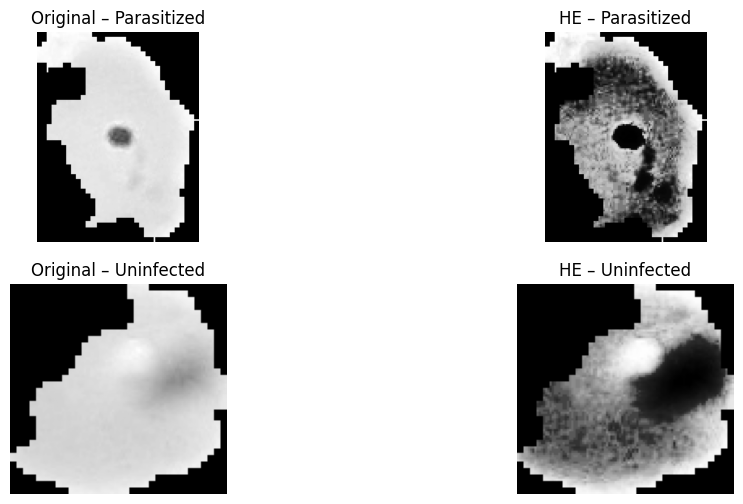

In [ ]:
plt.figure(figsize=(12,6))

# Parasitized
plt.subplot(2,2,1)
plt.imshow(gray_para, cmap='gray')
plt.title("Original – Parasitized")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(he_para, cmap='gray')
plt.title("HE – Parasitized")
plt.axis('off')

# Uninfected
plt.subplot(2,2,3)
plt.imshow(gray_uninf, cmap='gray')
plt.title("Original – Uninfected")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(he_uninf, cmap='gray')
plt.title("HE – Uninfected")
plt.axis('off')

plt.show()


/tmp/ipython-input-1258917522.py:5: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(original.flatten(), 256, [0,256], color='blue')
/tmp/ipython-input-1258917522.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.flatten(), 256, [0,256], color='green')


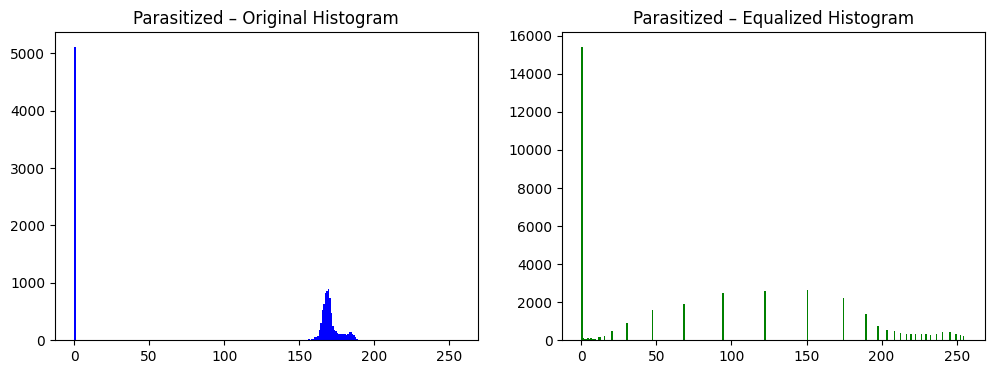

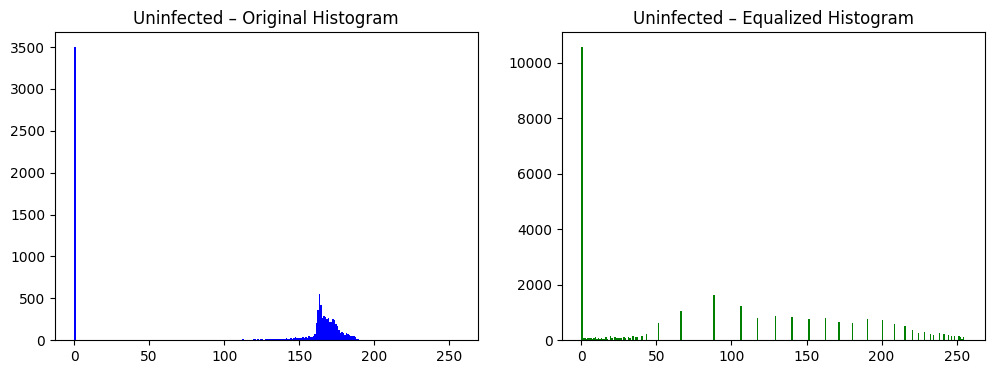

In [ ]:
def plot_histograms(original, equalized, title_prefix):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(original.flatten(), 256, [0,256], color='blue')
    plt.title(f"{title_prefix} – Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(equalized.flatten(), 256, [0,256], color='green')
    plt.title(f"{title_prefix} – Equalized Histogram")

    plt.show()

plot_histograms(gray_para, he_para, "Parasitized")
plot_histograms(gray_uninf, he_uninf, "Uninfected")


In [ ]:
import cv2
import os
from tqdm import tqdm
import numpy as np
import shutil

base_dir = "/content/drive/MyDrive/cell_project"
raw_dir  = os.path.join(base_dir, "RAW")
he_dir   = os.path.join(base_dir, "HE")

classes = ["Parasitized", "Uninfected"]
splits = ["train", "val", "test"]

# Manual Histogram Equalization Function
def manual_hist_eq(img):

    # convert to gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # compute histogram
    hist, bins = np.histogram(gray.flatten(), 256, [0, 256])

    # compute CDF
    cdf = hist.cumsum()
    cdf = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf = cdf.astype('uint8')

    # apply equalization
    img_eq = cdf[gray]

    # convert back to BGR for saving
    img_eq_bgr = cv2.cvtColor(img_eq, cv2.COLOR_GRAY2BGR)

    return img_eq_bgr  # ONLY return the equalized image


#Creating Output Directory Structure
for split in splits:
    for cls in classes:
        out_path = os.path.join(he_dir, split, cls)
        os.makedirs(out_path, exist_ok=True)

print("HE folder structure created.\n")

#Process RAW - HE for all splits/classes
for split in splits:
    print(f"\n=== Processing {split.upper()} ===")

    for cls in classes:

        input_path = os.path.join(raw_dir, split, cls)
        output_path = os.path.join(he_dir, split, cls)

        images = os.listdir(input_path)

        for file in tqdm(images, desc=f"{split}/{cls}"):
            src = os.path.join(input_path, file)
            dst = os.path.join(output_path, file)

            try:
                img = cv2.imread(src)
                if img is None:
                    continue

                img_eq = manual_hist_eq(img)
                cv2.imwrite(dst, img_eq)

            except Exception as e:
                print(f"Error processing {src}: {e}")
                continue

print("\n HE preprocessing completed successfully!")


In [ ]:
import os

# Define the root of your HE dataset
he_root = '/content/drive/MyDrive/cell_project/HE'

print(f"File counts in HE dataset subfolders (under {he_root}):")

# Iterate through the main splits (train, val, test)
for split_name in ['train', 'val', 'test']:
    split_path = os.path.join(he_root, split_name)
    print(f"\n--- {split_name.upper()} ---")

    # Iterate through the classes within each split
    for class_name in ['Parasitized', 'Uninfected']:
        class_path = os.path.join(split_path, class_name)

        if os.path.exists(class_path) and os.path.isdir(class_path):
            num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
            print(f"  {class_name}: {num_files} files")
        else:
            print(f"  {class_name}: Directory not found or is empty.")

    # Also count total files in the split for a quick check
    total_split_files = 0
    if os.path.exists(split_path):
        for root, _, files in os.walk(split_path):
            total_split_files += len(files)
    print(f"Total files in {split_name.upper()} split: {total_split_files}")


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Base project path
base_proj_path = "/content/drive/MyDrive/cell_project"

# RAW dataset root (already split)
raw_root = os.path.join(base_proj_path, "RAW")

# Output root for Fourier-filtered images
fourier_root = os.path.join(base_proj_path, "FOURIER_FILTERED")

os.makedirs(fourier_root, exist_ok=True)

splits = ["train", "val", "test"]
classes = ["Parasitized", "Uninfected"]
print("RAW root:", raw_root)
print("FOURIER root:", fourier_root)


RAW root: /content/drive/MyDrive/cell_project/RAW
FOURIER root: /content/drive/MyDrive/cell_project/FOURIER_FILTERED


In [ ]:
def low_pass_mask(shape, cutoff_radius):
    """
    Create a circular low-pass mask of given cutoff_radius.
    shape: (rows, cols) of the grayscale image.
    """
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2  # center

    Y, X = np.ogrid[:rows, :cols]
    dist_from_center = np.sqrt((X - ccol)**2 + (Y - crow)**2)

    mask = np.zeros((rows, cols), np.uint8)
    mask[dist_from_center <= cutoff_radius] = 1
    return mask


def fourier_lowpass_filter(img_bgr, cutoff_radius=30):
    """
    Apply 2D DFT, circular low-pass filtering, inverse DFT.
    Returns:
      - filtered_gray_uint8: filtered image in spatial domain (uint8)
      - mag_spectrum_before: magnitude spectrum before filtering (for visualization)
      - mag_spectrum_after: magnitude spectrum after filtering (for visualization)
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # DFT
    dft = cv2.dft(np.float32(gray), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Magnitude spectrum BEFORE filtering (for visualization)
    mag_before = cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1])
    mag_before = np.log(1 + mag_before)  # log-scaling for visibility

    # Build low-pass mask
    mask = low_pass_mask(gray.shape, cutoff_radius)
    mask_2ch = np.repeat(mask[:, :, np.newaxis], 2, axis=2)  # make it 2-channel

    # Apply mask
    dft_shift_filtered = dft_shift * mask_2ch

    # Magnitude spectrum AFTER filtering
    mag_after = cv2.magnitude(dft_shift_filtered[:,:,0], dft_shift_filtered[:,:,1])
    mag_after = np.log(1 + mag_after)

    # Inverse DFT
    f_ishift = np.fft.ifftshift(dft_shift_filtered)
    img_back_complex = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back_complex[:,:,0], img_back_complex[:,:,1])

    # Normalize to 0–255, uint8
    img_back_norm = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    img_back_uint8 = img_back_norm.astype("uint8")

    return img_back_uint8, mag_before, mag_after


Microscopy cell images contain high-frequency sensor noise and fine artifacts that are not clinically relevant. A circular low-pass filter preserves the global cell structure while suppressing high-frequency noise, helping the CNN focus on larger parasite/non-parasite patterns rather than pixel-level noise.

Sample image: /content/drive/MyDrive/cell_project/RAW/train/Parasitized/C39P4thinF_original_IMG_20150622_113842_cell_38.png


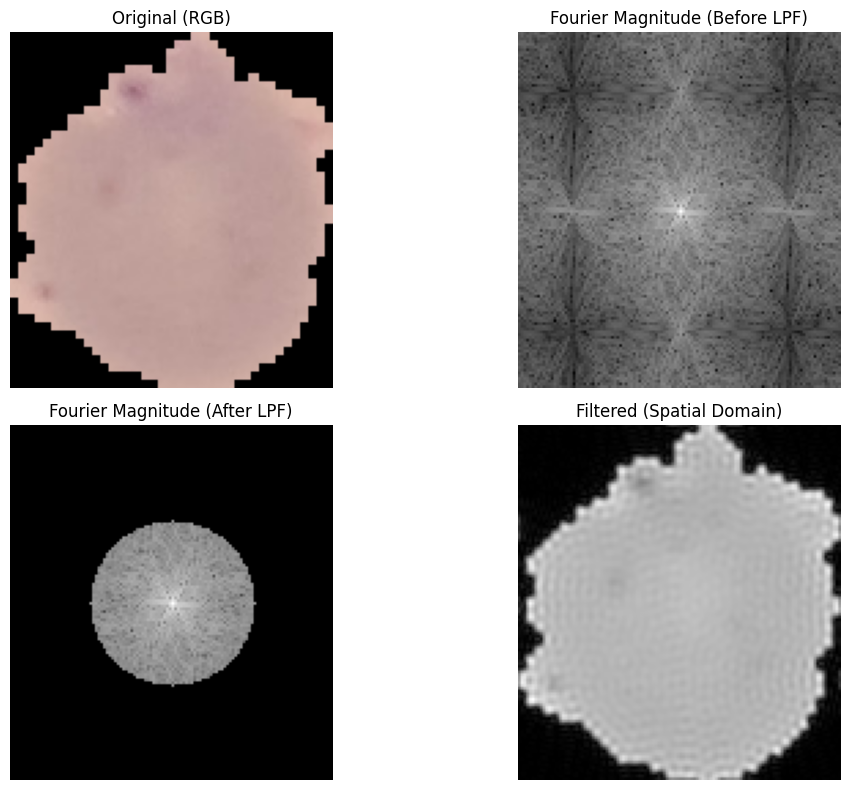

In [ ]:
# Pick one sample image for visualization
sample_path = None
sample_split = "train"
sample_class = "Parasitized"

sample_dir = os.path.join(raw_root, sample_split, sample_class)
for f in os.listdir(sample_dir):
    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
        sample_path = os.path.join(sample_dir, f)
        break

print("Sample image:", sample_path)

# Load and process
sample_img = cv2.imread(sample_path)
sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

filtered_gray, mag_before, mag_after = fourier_lowpass_filter(sample_img, cutoff_radius=30)

# Plot original, spectra, filtered
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(sample_img_rgb)
plt.title("Original (RGB)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mag_before, cmap='gray')
plt.title("Fourier Magnitude (Before LPF)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(mag_after, cmap='gray')
plt.title("Fourier Magnitude (After LPF)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(filtered_gray, cmap='gray')
plt.title("Filtered (Spatial Domain)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# CONFIG
raw_root = '/content/drive/MyDrive/cell_project/RAW'
fourier_root = '/content/drive/MyDrive/cell_project/FOURIER_FILTERED'

splits = ['train', 'val', 'test']
classes = ['Parasitized', 'Uninfected']

cutoff_radius = 15
# Fourier helper functions
def low_pass_filter(dft_shift, radius):
    rows, cols = dft_shift.shape[:2]
    crow, ccol = rows // 2, cols // 2

    mask = np.zeros((rows, cols, 2), np.uint8)
    Y, X = np.ogrid[:rows, :cols]
    dist = np.sqrt((X - ccol) ** 2 + (Y - crow) ** 2)
    mask[dist <= radius] = 1
    return dft_shift * mask

def fourier_lowpass_gray(img_gray, radius=15):
    # DFT
    dft = cv2.dft(np.float32(img_gray), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Apply low-pass mask
    filtered_shift = low_pass_filter(dft_shift, radius)

    # Inverse DFT
    f_ishift = np.fft.ifftshift(filtered_shift)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Normalize to uint8
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
    return img_back.astype('uint8')

# Create output folders
print(f"Saving Fourier-filtered images to: {fourier_root}")

for split in splits:
    for cls in classes:
        out_dir = os.path.join(fourier_root, split, cls)
        os.makedirs(out_dir, exist_ok=True)


# Main splitting processing loop

total_processed = 0
total_errors = 0

for split in splits:
    for cls in classes:
        in_dir = os.path.join(raw_root, split, cls)
        out_dir = os.path.join(fourier_root, split, cls)

        if not os.path.exists(in_dir):
            print(f"Input folder not found: {in_dir}")
            continue

        files = [f for f in os.listdir(in_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        print(f"\nProcessing {split}/{cls}: {len(files)} images")

        for fname in tqdm(files, desc=f"{split}/{cls}", leave=False):
            try:
                in_path = os.path.join(in_dir, fname)
                out_path = os.path.join(out_dir, fname)

                img_gray = cv2.imread(in_path, cv2.IMREAD_GRAYSCALE)
                if img_gray is None:
                    print(f" Could not read {in_path}, skipping.")
                    total_errors += 1
                    continue

                filtered = fourier_lowpass_gray(img_gray, radius=cutoff_radius)

                ok = cv2.imwrite(out_path, filtered)
                if not ok:
                    print(f"Failed to save {out_path}")
                    total_errors += 1
                else:
                    total_processed += 1

            except Exception as e:
                print(f"   Error on {in_path}: {e}")
                total_errors += 1

print("\n Fourier preprocessing completed.")
print(f"Total processed images: {total_processed}")
print(f"Total errors: {total_errors}")
print(f"Output root: {fourier_root}")


Saving Fourier-filtered images to: /content/drive/MyDrive/cell_project/FOURIER_FILTERED

Processing train/Parasitized: 9645 images



Processing train/Uninfected: 9645 images


train/Uninfected:  88%|████████▊ | 8534/9645 [37:58<07:36,  2.43it/s]

 Could not read /content/drive/MyDrive/cell_project/RAW/train/Uninfected/C237ThinF_IMG_20151127_104844_cell_222.png, skipping.



Processing val/Parasitized: 2067 images



Processing val/Uninfected: 2067 images



Processing test/Parasitized: 2067 images



Processing test/Uninfected: 2067 images



 Fourier preprocessing completed.
Total processed images: 27557
Total errors: 1
Output root: /content/drive/MyDrive/cell_project/FOURIER_FILTERED


Model training


In [ ]:
import os

root = "/content/drive/MyDrive/cell_project"

for dirpath, dirnames, filenames in os.walk(root):
    print(dirpath, "-->", len(filenames), "files")


In [ ]:
print(train_gen.class_indices)
print(len(train_gen))
batch = next(train_gen)
print(batch[0].shape, batch[1][:10])


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

# PATHS
BASE_DIR = "/content/drive/MyDrive/cell_project"
RAW_DIR  = os.path.join(BASE_DIR, "RAW")

train_dir = os.path.join(RAW_DIR, "train")
val_dir   = os.path.join(RAW_DIR, "val")
test_dir  = os.path.join(RAW_DIR, "test")

print("Train dir:", train_dir)
print("Val dir:  ", val_dir)
print("Test dir: ", test_dir)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32


In [ ]:
# Augmentation for training, only rescale for val/test
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)


In [ ]:
import matplotlib.pyplot as plt

batch_imgs, batch_labels = next(train_gen)
print("Batch shape:", batch_imgs.shape)
print("First 10 labels:", batch_labels[:10])

plt.imshow(batch_imgs[0])
plt.title(f"Label: {batch_labels[0]}")
plt.axis("off")
plt.show()


In [ ]:
def build_simple_cnn(input_shape=(128, 128, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Conv2D(128, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

model = build_simple_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model.summary()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint_path = os.path.join(BASE_DIR, "best_raw_cnn.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
]

EPOCHS = 15

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)


In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/cell_project/best_raw_cnn.keras")
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print(test_loss, test_acc, test_auc, test_prec, test_recall)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_true = test_gen.classes
y_pred = (model.predict(test_gen) > 0.5).astype("int32")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np

def build_cnn(input_shape=(224,224,3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
    )
    return model


In [ ]:
he_path = "/content/drive/MyDrive/cell_project/HE"

datagen = ImageDataGenerator(rescale=1/255.)

train_gen = datagen.flow_from_directory(
    os.path.join(he_path, "train"),
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

val_gen = datagen.flow_from_directory(
    os.path.join(he_path, "val"),
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

test_gen = datagen.flow_from_directory(
    os.path.join(he_path, "test"),
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/cell_project/best_he_cnn.keras"

callbacks = [
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor="val_loss", mode="min"),
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]


In [ ]:
model_he = build_cnn()

history_he = model_he.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)


In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/cell_project/best_he_cnn.keras")
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print(test_loss, test_acc, test_auc, test_prec, test_recall)



In [ ]:
from PIL import Image
import os
from tqdm import tqdm

def remove_corrupted_images(root_path):
    removed = 0
    checked = 0

    print(f"\n Scanning for corrupted images in:\n{root_path}\n")

    for subdir, _, files in os.walk(root_path):
        for file in tqdm(files, desc=subdir):
            filepath = os.path.join(subdir, file)
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            checked += 1
            try:
                img = Image.open(filepath)
                img.verify()  # detect corruption
            except Exception:
                print(f" Corrupted: {filepath}")
                removed += 1
                os.remove(filepath)  # delete it

    print(f"\n Done scanning {root_path}")
    print(f"  Checked: {checked}")
    print(f"  Removed corrupted: {removed}\n")


# RUN FOR ALL DATASETS
remove_corrupted_images("/content/drive/MyDrive/cell_project/RAW")
remove_corrupted_images("/content/drive/MyDrive/cell_project/HE")
remove_corrupted_images("/content/drive/MyDrive/cell_project/FOURIER_FILTERED")


In [ ]:
model = tf.keras.models.load_model("/content/drive/MyDrive/cell_project/best_he_cnn.keras")
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print(test_loss, test_acc, test_auc, test_prec, test_recall)

In [ ]:
fourier_root = "/content/drive/MyDrive/cell_project/FOURIER_FILTERED"


In [ ]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(fourier_root, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    os.path.join(fourier_root, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(fourier_root, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 19290 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.


In [ ]:
def build_cnn_model():
    model = models.Sequential([
        layers.Input(shape=(224,224,3)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )
    return model

model = build_cnn_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/cell_project/best_fourier_cnn.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]


In [ ]:
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 7577s 13s/step - accuracy: 0.5473 - auc: 0.5671 - loss: 0.6869 - precision: 0.5418 - recall: 0.5515 - val_accuracy: 0.6280 - val_auc: 0.6832 - val_loss: 0.6473 - val_precision: 0.6297 - val_recall: 0.6212 - learning_rate: 1.0000e-04
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 2521s 4s/step - accuracy: 0.6464 - auc: 0.6995 - loss: 0.6311 - precision: 0.6691 - recall: 0.5818 - val_accuracy: 0.7383 - val_auc: 0.8232 - val_loss: 0.5364 - val_precision: 0.7240 - val_recall: 0.7702 - learning_rate: 1.0000e-04
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 2511s 4s/step - accuracy: 0.7383 - auc: 0.8215 - loss: 0.5262 - precision: 0.7516 - recall: 0.7126 - val_accuracy: 0.7866 - val_auc: 0.9095 - val_loss: 0.4514 - val_precision: 0.7215 - val_recall: 0.9337 - learning_rate: 1.0000e-04
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 2515s 4s/step - accuracy: 0.8250 - auc: 0.9005 - loss: 0.4165 - precision: 0.8137 - recall: 0.8475 - val_accuracy: 0.8788 - val_auc: 0.9466 - v

In [ ]:
test_loss, test_acc, test_auc, test_prec, test_recall = model.evaluate(test_gen)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)
print("Test Precision:", test_prec)
print("Test Recall:", test_recall)


In [ ]:
y_true = test_gen.classes
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Parasitized","Uninfected"],
            yticklabels=["Parasitized","Uninfected"])
plt.title("CONFUSION MATRIX (FOURIER)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))


Loading models...
  Raw model expects:     (128, 128)
  HE model expects:      (224, 224)
  Fourier model expects: (224, 224)

CROSS-PIPELINE EVALUATION  (9 combinations)

Found 4134 images belonging to 2 classes.
  Raw      → Raw      | Acc=0.9596  Prec=0.9473  Rec=0.9734  F1=0.9602  FP=112  FN=55  Errors=167
Found 4133 images belonging to 2 classes.
  Raw      → HE       | Acc=0.5429  Prec=0.5229  Rec=0.9777  F1=0.6814  FP=1843  FN=46  Errors=1889
Found 4134 images belonging to 2 classes.
  Raw      → Fourier  | Acc=0.5010  Prec=0.5005  Rec=0.9995  F1=0.6670  FP=2062  FN=1  Errors=2063
Found 4134 images belonging to 2 classes.
  HE       → Raw      | Acc=0.5223  Prec=0.5119  Rec=0.9579  F1=0.6672  FP=1888  FN=87  Errors=1975
Found 4133 images belonging to 2 classes.
  HE       → HE       | Acc=0.9243  Prec=0.9372  Rec=0.9095  F1=0.9231  FP=126  FN=187  Errors=313
Found 4134 images belonging to 2 classes.
  HE       → Fourier  | Acc=0.5331  Prec=0.5192  Rec=0.8955  F1=0.6573  FP=1714 

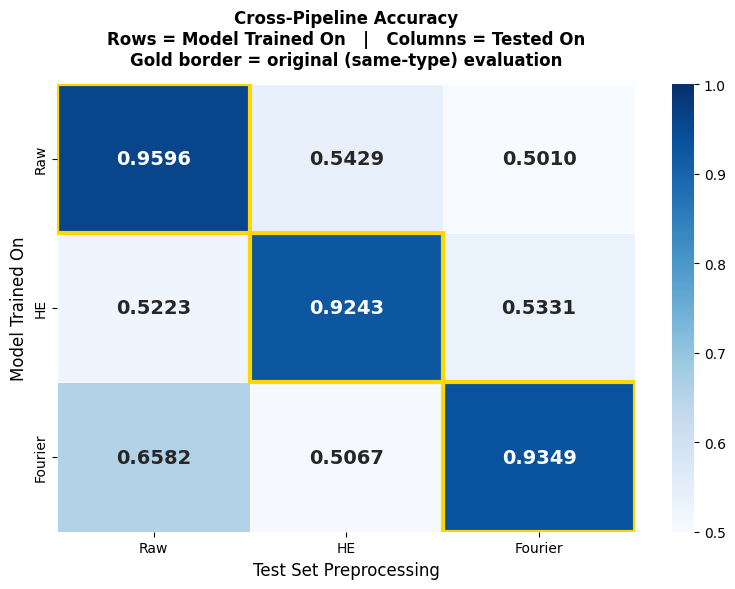

Saved: cross_pipeline_accuracy.png


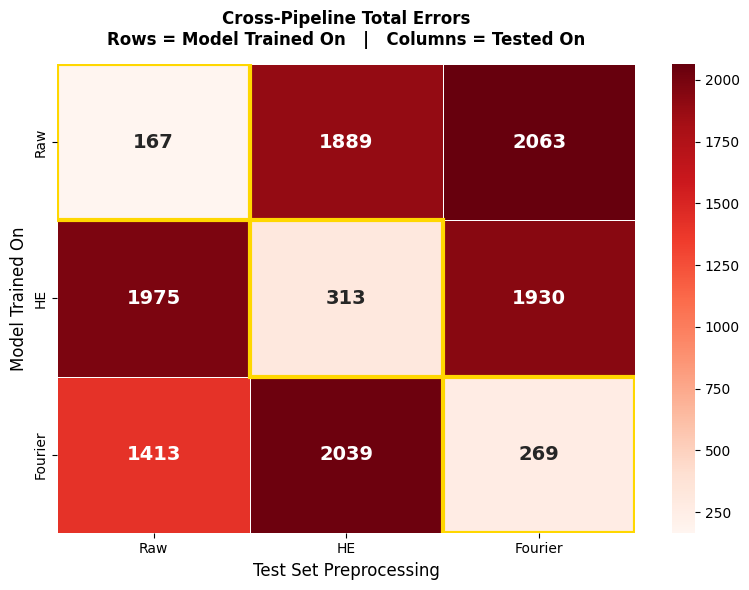


SUMMARY ANALYSIS

Mean accuracy — same preprocessing : 0.9396
Mean accuracy — cross preprocessing: 0.5440
Average drop when model sees unseen preprocessing: 0.3956

Per-model robustness (how much each model drops on unseen data):
  Raw      | Same: 0.9596 | Cross avg: 0.5220 | Drop: 0.4376
  HE       | Same: 0.9243 | Cross avg: 0.5277 | Drop: 0.3966
  Fourier  | Same: 0.9349 | Cross avg: 0.5825 | Drop: 0.3524

Results saved to /content/drive/MyDrive/cell_project/cross_pipeline_results.csv


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

BASE_DIR     = "/content/drive/MyDrive/cell_project"
RAW_TEST     = f"{BASE_DIR}/RAW/test"
HE_TEST      = f"{BASE_DIR}/HE/test"
FOURIER_TEST = f"{BASE_DIR}/FOURIER_FILTERED/test"

# Load all three saved models
print("Loading models...")
raw_model     = tf.keras.models.load_model(f"{BASE_DIR}/best_raw_cnn.keras")
he_model      = tf.keras.models.load_model(f"{BASE_DIR}/best_he_cnn.keras")
fourier_model = tf.keras.models.load_model(f"{BASE_DIR}/best_fourier_cnn.keras")

# Confirm each model's expected input size
raw_size     = raw_model.input_shape[1:3]
he_size      = he_model.input_shape[1:3]
fourier_size = fourier_model.input_shape[1:3]

print(f"  Raw model expects:     {raw_size}")
print(f"  HE model expects:      {he_size}")
print(f"  Fourier model expects: {fourier_size}")

# Generator factory — builds at the correct size
datagen = ImageDataGenerator(rescale=1./255)

def make_gen(test_dir, img_size):
    return datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=32,
        class_mode="binary",
        shuffle=False        # CRITICAL — keeps y_true aligned
    )

#  Evaluation function
def evaluate_cross(model, model_name, model_size, test_dir, test_name):
    gen = make_gen(test_dir, model_size)
    gen.reset()

    y_true      = gen.classes
    y_pred_prob = model.predict(gen, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)
    fp   = int(cm[0][1])
    fn   = int(cm[1][0])

    print(f"  {model_name:8s} → {test_name:8s} | "
          f"Acc={acc:.4f}  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}  "
          f"FP={fp}  FN={fn}  Errors={fp+fn}")

    return {
        "Model Trained On": model_name,
        "Tested On":        test_name,
        "Accuracy":         round(acc,  4),
        "Precision":        round(prec, 4),
        "Recall":           round(rec,  4),
        "F1 Score":         round(f1,   4),
        "FP":               fp,
        "FN":               fn,
        "Total Errors":     fp + fn
    }

#  Run all 9 combinations
# Each model uses its OWN expected image size for ALL three test sets
# The test set images are resized on-the-fly by the generator

print("\n" + "="*65)
print("CROSS-PIPELINE EVALUATION  (9 combinations)")
print("="*65 + "\n")

experiments = [
    # (model,         model_name, model_size,   test_dir,     test_name)
    (raw_model,     "Raw",     raw_size,     RAW_TEST,     "Raw"),
    (raw_model,     "Raw",     raw_size,     HE_TEST,      "HE"),
    (raw_model,     "Raw",     raw_size,     FOURIER_TEST, "Fourier"),

    (he_model,      "HE",      he_size,      RAW_TEST,     "Raw"),
    (he_model,      "HE",      he_size,      HE_TEST,      "HE"),
    (he_model,      "HE",      he_size,      FOURIER_TEST, "Fourier"),

    (fourier_model, "Fourier", fourier_size, RAW_TEST,     "Raw"),
    (fourier_model, "Fourier", fourier_size, HE_TEST,      "HE"),
    (fourier_model, "Fourier", fourier_size, FOURIER_TEST, "Fourier"),
]

results = []
for (model, model_name, model_size, test_dir, test_name) in experiments:
    r = evaluate_cross(model, model_name, model_size, test_dir, test_name)
    results.append(r)

#  Results table
df = pd.DataFrame(results)
print("\n\nFULL RESULTS TABLE:")
print(df.to_string(index=False))

#  Accuracy heatmap
order = ["Raw", "HE", "Fourier"]

acc_matrix = df.pivot(
    index="Model Trained On",
    columns="Tested On",
    values="Accuracy"
).loc[order, order]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    acc_matrix,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    linewidths=0.5,
    vmin=0.5, vmax=1.0,
    annot_kws={"size": 14, "weight": "bold"}
)
# Mark the diagonal (same-type results) with a border
for i in range(len(order)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                 fill=False, edgecolor="gold", lw=3))

plt.title(
    "Cross-Pipeline Accuracy\n"
    "Rows = Model Trained On   |   Columns = Tested On\n"
    "Gold border = original (same-type) evaluation",
    fontsize=12, fontweight="bold", pad=14
)
plt.xlabel("Test Set Preprocessing", fontsize=12)
plt.ylabel("Model Trained On", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/cross_pipeline_accuracy.png", dpi=300)
plt.show()
print("Saved: cross_pipeline_accuracy.png")

#  Error heatmap
err_matrix = df.pivot(
    index="Model Trained On",
    columns="Tested On",
    values="Total Errors"
).loc[order, order]

plt.figure(figsize=(8, 6))
ax2 = sns.heatmap(
    err_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    annot_kws={"size": 14, "weight": "bold"}
)
for i in range(len(order)):
    ax2.add_patch(plt.Rectangle((i, i), 1, 1,
                  fill=False, edgecolor="gold", lw=3))

plt.title(
    "Cross-Pipeline Total Errors\n"
    "Rows = Model Trained On   |   Columns = Tested On",
    fontsize=12, fontweight="bold", pad=14
)
plt.xlabel("Test Set Preprocessing", fontsize=12)
plt.ylabel("Model Trained On", fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/cross_pipeline_errors.png", dpi=300)
plt.show()

#  the Key analysis summary
print("\n" + "="*65)
print("SUMMARY ANALYSIS")
print("="*65)

diagonal     = df[df["Model Trained On"] == df["Tested On"]]
off_diagonal = df[df["Model Trained On"] != df["Tested On"]]

print(f"\nMean accuracy — same preprocessing : {diagonal['Accuracy'].mean():.4f}")
print(f"Mean accuracy — cross preprocessing: {off_diagonal['Accuracy'].mean():.4f}")
print(f"Average drop when model sees unseen preprocessing: "
      f"{diagonal['Accuracy'].mean() - off_diagonal['Accuracy'].mean():.4f}")

print("\nPer-model robustness (how much each model drops on unseen data):")
for m in order:
    same  = df[(df["Model Trained On"]==m) & (df["Tested On"]==m)]["Accuracy"].values[0]
    cross = df[(df["Model Trained On"]==m) & (df["Tested On"]!=m)]["Accuracy"].mean()
    print(f"  {m:8s} | Same: {same:.4f} | Cross avg: {cross:.4f} | Drop: {same-cross:.4f}")

df.to_csv(f"{BASE_DIR}/cross_pipeline_results.csv", index=False)
print(f"\nResults saved to {BASE_DIR}/cross_pipeline_results.csv")

In [ ]:

# 5-FOLD CROSS-VALIDATION
# Reads directly from your existing Drive folders
# RAW / HE / FOURIER_FILTERED — all confirmed present


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef,
                             confusion_matrix)
from glob import glob
import cv2

# Configuration
BASE_DIR  = "/content/drive/MyDrive/cell_project"
CV_DIR    = os.path.join(BASE_DIR, "cv_results")
os.makedirs(CV_DIR, exist_ok=True)

N_FOLDS    = 5
EPOCHS     = 15
BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
SEED       = 42

print("✓ Configuration set")
print(f"  Base:    {BASE_DIR}")
print(f"  CV out:  {CV_DIR}")
print(f"  Folds:   {N_FOLDS}")
print(f"  Epochs:  {EPOCHS} (with early stopping)")


# Load all image paths from Drive folders
# Combines train + val + test so CV re-splits everything cleanly
# This avoids any leakage from the original fixed split

def collect_all_paths(pipeline_name):
    pipeline_dir = os.path.join(BASE_DIR, pipeline_name)
    paths, labels = [], []

    for split in ["train", "val", "test"]:
        for cls, label in [("Parasitized", 1), ("Uninfected", 0)]:
            folder = os.path.join(pipeline_dir, split, cls)
            imgs   = (glob(f"{folder}/*.png") +
                      glob(f"{folder}/*.jpg"))
            paths.extend(imgs)
            labels.extend([label] * len(imgs))

    paths  = np.array(paths)
    labels = np.array(labels)
    print(f"  {pipeline_name:20s}: {len(paths)} images  "
          f"({labels.sum()} parasitized, "
          f"{(labels==0).sum()} uninfected)")
    return paths, labels

print("\nLoading image paths from Google Drive...")
raw_paths,     raw_labels     = collect_all_paths("RAW")
he_paths,      he_labels      = collect_all_paths("HE")
fourier_paths, fourier_labels = collect_all_paths("FOURIER_FILTERED")
print(" All paths loaded")


# CNN — same architecture as your original training
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Image generator from file paths
def path_generator(paths, labels, batch_size,
                   img_size, augment=False):
    n       = len(paths)
    indices = np.arange(n)

    while True:
        if augment:
            np.random.shuffle(indices)

        for start in range(0, n, batch_size):
            batch_idx = indices[start : start + batch_size]
            batch_x   = []
            batch_y   = labels[batch_idx]

            for idx in batch_idx:
                img = cv2.imread(paths[idx])
                if img is None:
                    img = np.zeros(
                        (img_size[0], img_size[1], 3), dtype=np.uint8
                    )
                img = cv2.resize(img, img_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                if augment:
                    if np.random.rand() > 0.5:
                        img = cv2.flip(img, 1)   # horizontal flip
                    if np.random.rand() > 0.5:
                        img = cv2.flip(img, 0)   # vertical flip
                    factor = np.random.uniform(0.9, 1.1)
                    img = np.clip(
                        img.astype(np.float32) * factor, 0, 255
                    ).astype(np.uint8)

                batch_x.append(img.astype(np.float32) / 255.0)

            yield np.array(batch_x), batch_y.astype(np.float32)

def n_steps(n_samples, batch_size):
    return int(np.ceil(n_samples / batch_size))


# Single fold
def run_fold(fold_idx, train_paths, train_labels,
             val_paths, val_labels, pipeline_name):

    n_train = len(train_paths)
    n_val   = len(val_paths)
    print(f"\n    Fold {fold_idx+1} | Train={n_train}  Val={n_val}")

    tf.keras.backend.clear_session()
    model     = build_cnn()
    ckpt_path = os.path.join(
        CV_DIR, f"{pipeline_name}_fold{fold_idx+1}.keras"
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=3,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6, verbose=0),
        ModelCheckpoint(ckpt_path, monitor="val_loss",
                        save_best_only=True, verbose=0)
    ]

    model.fit(
        path_generator(train_paths, train_labels,
                       BATCH_SIZE, IMG_SIZE, augment=True),
        steps_per_epoch  = n_steps(n_train, BATCH_SIZE),
        epochs           = EPOCHS,
        validation_data  = path_generator(val_paths, val_labels,
                                          BATCH_SIZE, IMG_SIZE,
                                          augment=False),
        validation_steps = n_steps(n_val, BATCH_SIZE),
        callbacks        = callbacks,
        verbose          = 0
    )

    # Evaluate using best saved checkpoint
    best = tf.keras.models.load_model(ckpt_path)

    y_true, y_prob = [], []
    eval_gen   = path_generator(val_paths, val_labels,
                                BATCH_SIZE, IMG_SIZE, augment=False)
    eval_steps = n_steps(n_val, BATCH_SIZE)

    for step, (bx, by) in enumerate(eval_gen):
        if step >= eval_steps:
            break
        probs = best.predict(bx, verbose=0).flatten()
        y_prob.extend(probs.tolist())
        y_true.extend(by.tolist())

    # Trim to exact sample count
    y_true = np.array(y_true[:n_val])
    y_prob = np.array(y_prob[:n_val])
    y_pred = (y_prob > 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)
    mcc  = matthews_corrcoef(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    fp   = int(cm[0][1])
    fn   = int(cm[1][0])

    print(f"    → Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  "
          f"F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}  "
          f"FP={fp}  FN={fn}")

    return {
        "Pipeline":  pipeline_name,
        "Fold":      fold_idx + 1,
        "Accuracy":  acc,
        "Precision": prec,
        "Recall":    rec,
        "F1":        f1,
        "AUC":       auc,
        "MCC":       mcc,
        "FP":        fp,
        "FN":        fn
    }


# Run all 3 pipelines × 5 folds = 15 training runs
skf = StratifiedKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=SEED
)

pipeline_data = [
    ("Raw",     raw_paths,     raw_labels),
    ("HE",      he_paths,      he_labels),
    ("Fourier", fourier_paths, fourier_labels),
]

all_results = []

for pipeline_name, paths, labels in pipeline_data:
    print("\n" + "="*60)
    print(f"PIPELINE: {pipeline_name}  ({len(paths)} total images)")
    print("="*60)

    for fold_idx, (train_idx, val_idx) in enumerate(
        skf.split(paths, labels)
    ):
        result = run_fold(
            fold_idx,
            paths[train_idx],  labels[train_idx],
            paths[val_idx],    labels[val_idx],
            pipeline_name
        )
        all_results.append(result)

    # Save after every pipeline  protects against session timeout
    pd.DataFrame(all_results).to_csv(
        os.path.join(CV_DIR, "cv_partial.csv"), index=False
    )
    print(f"\n   {pipeline_name} complete - results saved to Drive")


# Full results table
df = pd.DataFrame(all_results)
df.to_csv(os.path.join(CV_DIR, "cv_all_folds.csv"), index=False)

print("\n\n" + "="*60)
print("COMPLETE RESULTS — ALL FOLDS")
print("="*60)
print(df.to_string(index=False))


#  Summary table (mean ± std) — goes in your paper
print("\n\n" + "="*60)
print("SUMMARY TABLE  —  copy this into your paper")
print("="*60)

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC", "MCC"]
summary_rows = []

for p in ["Raw", "HE", "Fourier"]:
    sub = df[df["Pipeline"] == p]
    row = {"Pipeline": p}
    for m in metrics:
        v      = sub[m].values
        row[m] = f"{v.mean():.4f} ± {v.std():.4f}"
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
df_summary.to_csv(
    os.path.join(CV_DIR, "cv_summary.csv"), index=False
)


# Fold-by-fold line plots
colors = {"Raw":"#2563A8", "HE":"#C23B2E", "Fourier":"#1A8C4E"}
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    for p in ["Raw", "HE", "Fourier"]:
        sub  = df[df["Pipeline"] == p]
        vals = sub[metric].values
        ax.plot(sub["Fold"].values, vals, "o-",
                color=colors[p], label=p,
                linewidth=2, markersize=7)
        ax.axhline(vals.mean(), color=colors[p],
                   linestyle="--", linewidth=1, alpha=0.4)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_xlabel("Fold")
    ax.set_ylabel(metric)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "5-Fold Cross-Validation — All Metrics Across Pipelines",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(CV_DIR, "cv_fold_plots.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cv_fold_plots.png")


# Box plots for publication
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for i, metric in enumerate(["Accuracy", "F1", "AUC"]):
    ax   = axes[i]
    data = [df[df["Pipeline"] == p][metric].values
            for p in ["Raw", "HE", "Fourier"]]
    bp   = ax.boxplot(data, labels=["Raw", "HE", "Fourier"],
                      patch_artist=True)
    for patch, p in zip(bp["boxes"], ["Raw", "HE", "Fourier"]):
        patch.set_facecolor(colors[p])
        patch.set_alpha(0.7)
    ax.set_title(metric, fontweight="bold", fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(0.80, 1.02)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "5-Fold CV — Distribution of Key Metrics",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(CV_DIR, "cv_boxplots.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved: cv_boxplots.png")

print(f"\n All done. Results saved to {CV_DIR}")

✓ Configuration set
  Base:    /content/drive/MyDrive/cell_project
  CV out:  /content/drive/MyDrive/cell_project/cv_results
  Folds:   5
  Epochs:  15 (with early stopping)

Loading image paths from Google Drive...
  RAW                 : 27558 images  (13779 parasitized, 13779 uninfected)
  HE                  : 27557 images  (13779 parasitized, 13778 uninfected)
  FOURIER_FILTERED    : 27558 images  (13779 parasitized, 13779 uninfected)
✓ All paths loaded

PIPELINE: Raw  (27558 total images)

    Fold 1 | Train=22046  Val=5512


In [ ]:
import os

drive_root = "/content/drive/MyDrive"

print("Searching for .keras model files on Drive...\n")

for dirpath, dirnames, filenames in os.walk(drive_root):
    depth = dirpath.replace(drive_root, "").count(os.sep)
    if depth > 5:
        dirnames[:] = []
        continue
    for f in filenames:
        if f.endswith(".keras"):
            print(f"  {os.path.join(dirpath, f)}")

Searching for .keras model files on Drive...

  /content/drive/MyDrive/cell_project/best_raw_cnn.keras
  /content/drive/MyDrive/cell_project/best_he_cnn.keras
  /content/drive/MyDrive/cell_project/best_fourier_cnn.keras
  /content/drive/MyDrive/cell_project/cv_results/fold_1_Raw.keras
  /content/drive/MyDrive/cell_project/cv_results/Raw_fold1.keras


In [ ]:
 import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

DRIVE_DIR  = "/content/drive/MyDrive/cell_project"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Force Drive to wake up before loading
import os
os.listdir(DRIVE_DIR)

print("Loading models...")
raw_model     = tf.keras.models.load_model(f"{DRIVE_DIR}/best_raw_cnn.keras")
he_model      = tf.keras.models.load_model(f"{DRIVE_DIR}/best_he_cnn.keras")
fourier_model = tf.keras.models.load_model(f"{DRIVE_DIR}/best_fourier_cnn.keras")
print("All three models loaded.")

datagen = ImageDataGenerator(rescale=1./255)

def get_predictions(model, test_dir, img_size):
    gen = datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
    gen.reset()
    y_true = gen.classes
    y_prob = model.predict(gen, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    correct = (y_pred == y_true).astype(int)
    acc = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {acc:.4f}")
    return y_true, y_prob, y_pred, correct

print("\nRaw model (128x128)...")
raw_true, raw_prob, raw_pred, raw_correct = get_predictions(
    raw_model, f"{DRIVE_DIR}/RAW/test", (128, 128)
)

print("HE model (224x224)...")
he_true, he_prob, he_pred, he_correct = get_predictions(
    he_model, f"{DRIVE_DIR}/HE/test", (224, 224)
)

print("Fourier model (224x224)...")
fourier_true, fourier_prob, fourier_pred, fourier_correct = get_predictions(
    fourier_model, f"{DRIVE_DIR}/FOURIER_FILTERED/test", (224, 224)
)


def run_mcnemar(correct_a, correct_b, name_a, name_b):
    # Use the shorter array length to align both
    n = min(len(correct_a), len(correct_b))
    a = correct_a[:n]
    b = correct_b[:n]

    both_correct = np.sum((a == 1) & (b == 1))
    a_only       = np.sum((a == 1) & (b == 0))
    b_only       = np.sum((a == 0) & (b == 1))
    neither      = np.sum((a == 0) & (b == 0))

    table  = [[both_correct, a_only], [b_only, neither]]
    result = mcnemar(table, exact=False, correction=True)

    print(f"\n{name_a} vs {name_b}")
    print(f"  {name_a} correct, {name_b} wrong : {a_only}")
    print(f"  {name_b} correct, {name_a} wrong : {b_only}")
    print(f"  Chi-square : {result.statistic:.4f}")
    print(f"  p-value    : {result.pvalue:.6f}")
    if result.pvalue < 0.05:
        print(f"  Result     : STATISTICALLY SIGNIFICANT (p < 0.05)")
    else:
        print(f"  Result     : not significant (p >= 0.05)")


print("\nMcNemar Statistical Significance Tests")
print("=" * 50)
run_mcnemar(raw_correct, he_correct,      "Raw", "HE")
run_mcnemar(raw_correct, fourier_correct, "Raw", "Fourier")
run_mcnemar(he_correct,  fourier_correct, "HE",  "Fourier")

Loading models...
All three models loaded.

Raw model (128x128)...
Found 4134 images belonging to 2 classes.
  Accuracy: 0.9596
HE model (224x224)...
Found 4133 images belonging to 2 classes.
  Accuracy: 0.9243
Fourier model (224x224)...
Found 4134 images belonging to 2 classes.
  Accuracy: 0.9349

McNemar Statistical Significance Tests

Raw vs HE
  Raw correct, HE wrong : 232
  HE correct, Raw wrong : 86
  Chi-square : 66.1164
  p-value    : 0.000000
  Result     : STATISTICALLY SIGNIFICANT (p < 0.05)

Raw vs Fourier
  Raw correct, Fourier wrong : 144
  Fourier correct, Raw wrong : 42
  Chi-square : 54.8441
  p-value    : 0.000000
  Result     : STATISTICALLY SIGNIFICANT (p < 0.05)

HE vs Fourier
  HE correct, Fourier wrong : 159
  Fourier correct, HE wrong : 203
  Chi-square : 5.1077
  p-value    : 0.023819
  Result     : STATISTICALLY SIGNIFICANT (p < 0.05)


Getting predictions...
Found 4134 images belonging to 2 classes.
Found 4133 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Predictions ready. Building plots...


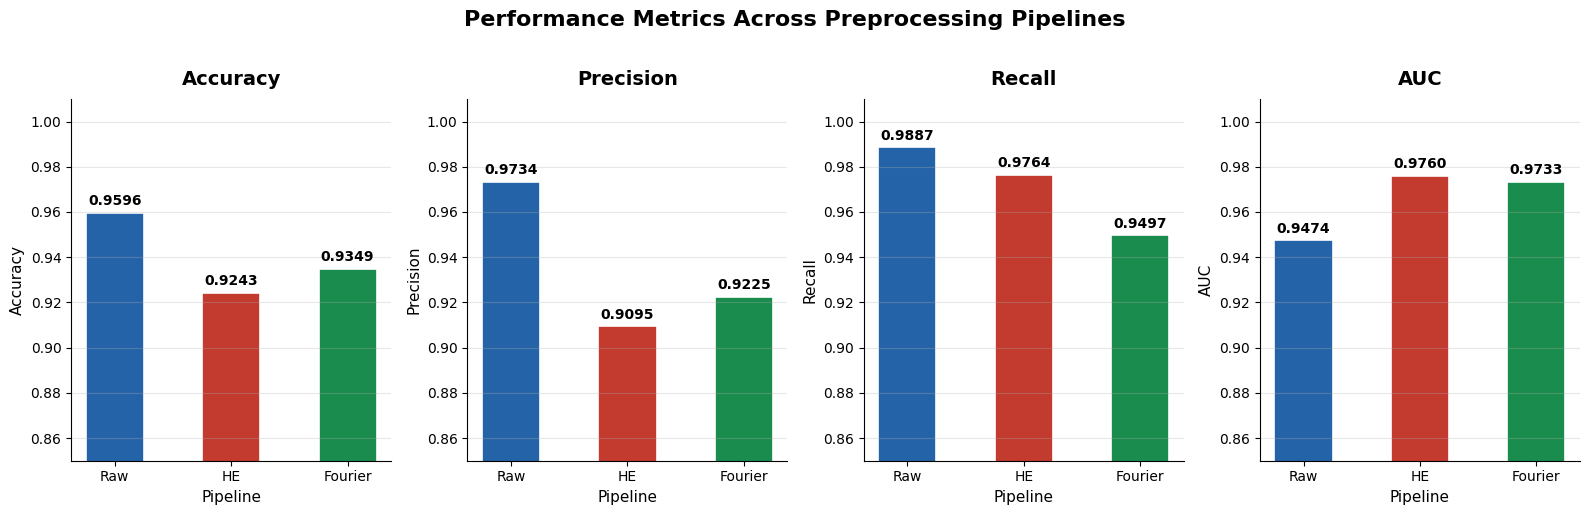

Plot 1 saved: Performance metrics bar chart


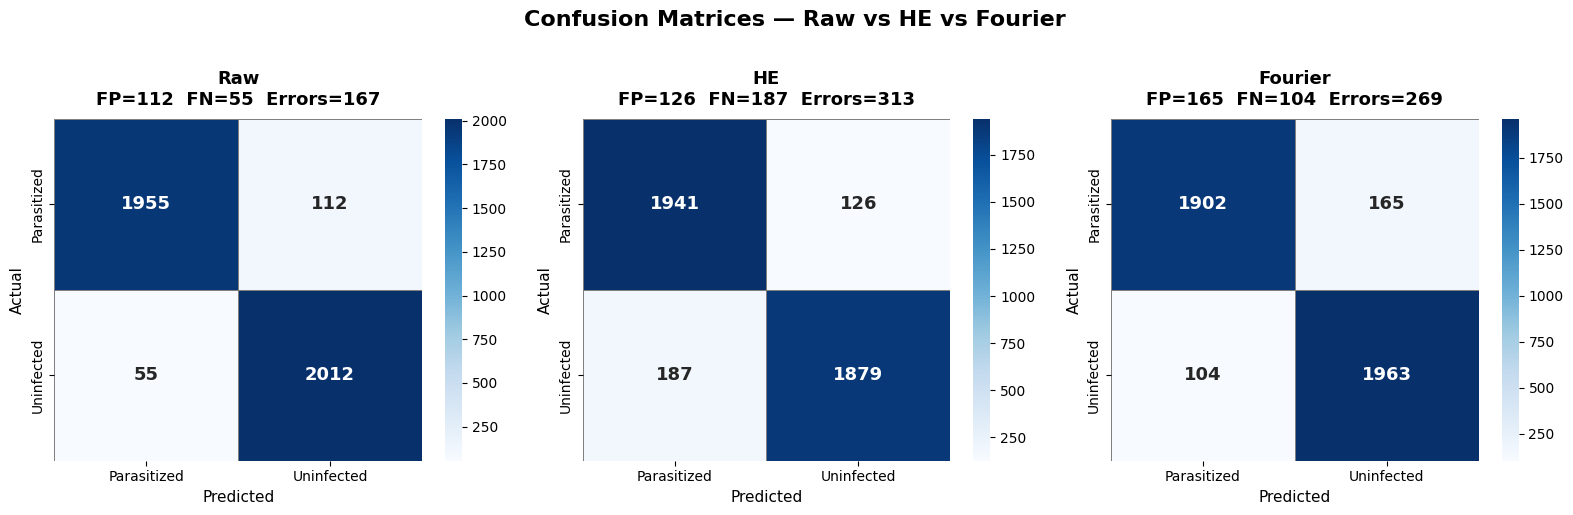

Plot 2 saved: Confusion matrices


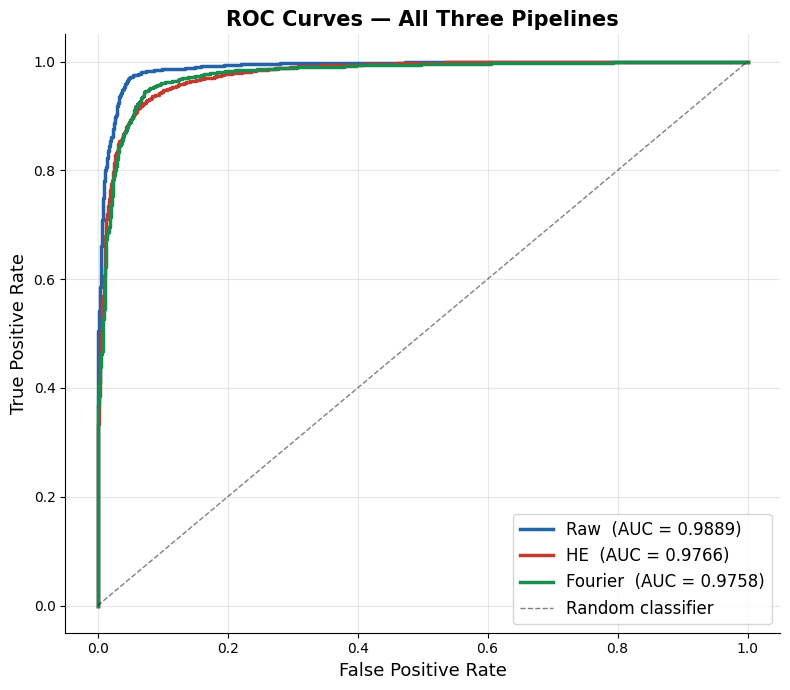

Plot 3 saved: ROC curves


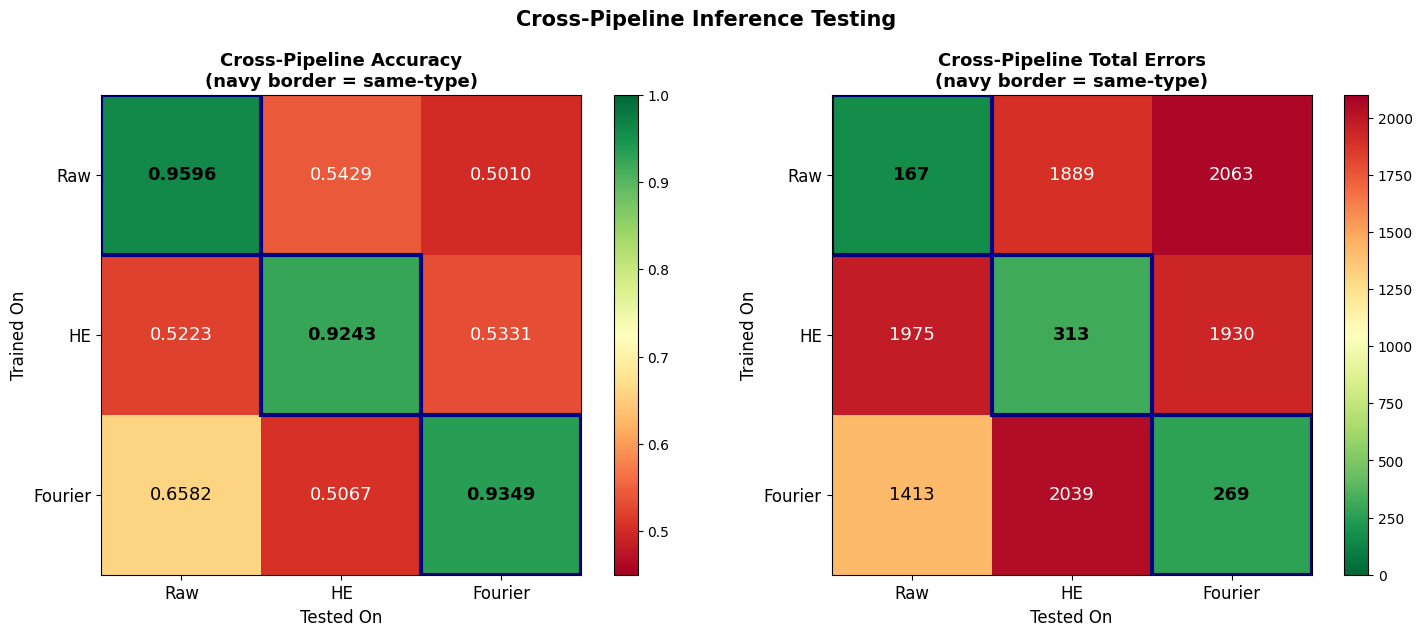

Plot 4 saved: Cross-pipeline heatmaps


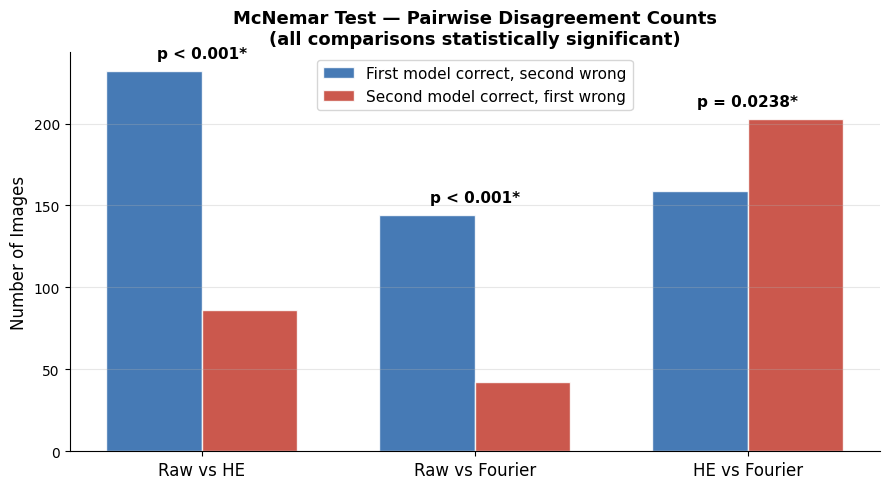

Plot 5 saved: McNemar test results


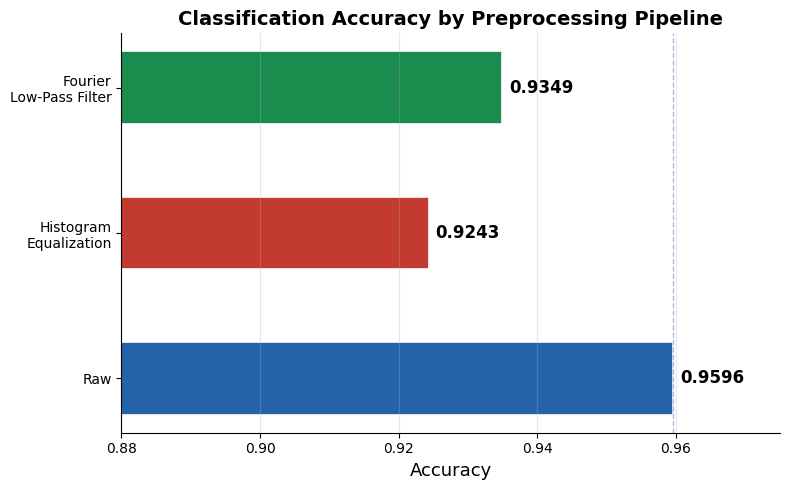

Plot 6 saved: Accuracy summary

All 6 plots saved to /content/drive/MyDrive/cell_project/plots

Plots produced:
  1. Performance metrics bar chart (Accuracy, Precision, Recall, AUC)
  2. Confusion matrices for all three pipelines
  3. ROC curves with AUC values
  4. Cross-pipeline inference heatmaps (accuracy and errors)
  5. McNemar test disagreement counts
  6. Horizontal accuracy summary bar chart


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay)

DRIVE_DIR  = "/content/drive/MyDrive/cell_project"
PLOTS_DIR  = f"{DRIVE_DIR}/plots"
import os
os.makedirs(PLOTS_DIR, exist_ok=True)

COLORS = {
    "Raw":     "#2563A8",
    "HE":      "#C23B2E",
    "Fourier": "#1A8C4E"
}

# Load models
os.listdir(DRIVE_DIR)
raw_model     = tf.keras.models.load_model(f"{DRIVE_DIR}/best_raw_cnn.keras")
he_model      = tf.keras.models.load_model(f"{DRIVE_DIR}/best_he_cnn.keras")
fourier_model = tf.keras.models.load_model(f"{DRIVE_DIR}/best_fourier_cnn.keras")

datagen = ImageDataGenerator(rescale=1./255)

def get_preds(model, test_dir, img_size):
    gen = datagen.flow_from_directory(
        test_dir, target_size=img_size,
        batch_size=32, class_mode="binary", shuffle=False
    )
    gen.reset()
    y_true = gen.classes
    y_prob = model.predict(gen, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    return y_true, y_prob, y_pred

print("Getting predictions...")
raw_true,     raw_prob,     raw_pred     = get_preds(raw_model,     f"{DRIVE_DIR}/RAW/test",              (128,128))
he_true,      he_prob,      he_pred      = get_preds(he_model,      f"{DRIVE_DIR}/HE/test",               (224,224))
fourier_true, fourier_prob, fourier_pred = get_preds(fourier_model, f"{DRIVE_DIR}/FOURIER_FILTERED/test", (224,224))
print("Predictions ready. Building plots...")


# ── PLOT 1: Performance metrics bar chart ─────────────────────────
metrics_data = {
    "Pipeline":  ["Raw",    "HE",    "Fourier"],
    "Accuracy":  [0.9596,   0.9243,  0.9349],
    "Precision": [0.9734,   0.9095,  0.9225],
    "Recall":    [0.9887,   0.9764,  0.9497],
    "AUC":       [0.9474,   0.9760,  0.9733],
}
df_metrics = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metric_names = ["Accuracy", "Precision", "Recall", "AUC"]

for i, metric in enumerate(metric_names):
    ax = axes[i]
    bars = ax.bar(
        df_metrics["Pipeline"],
        df_metrics[metric],
        color=[COLORS[p] for p in df_metrics["Pipeline"]],
        width=0.5, edgecolor="white", linewidth=1.2
    )
    ax.set_ylim(0.85, 1.01)
    ax.set_title(metric, fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel("Pipeline", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, df_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

plt.suptitle("Performance Metrics Across Preprocessing Pipelines",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot1_metrics_bar.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 1 saved: Performance metrics bar chart")


# ── PLOT 2: Confusion matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pipelines = [
    ("Raw",     raw_true,     raw_pred,     COLORS["Raw"]),
    ("HE",      he_true,      he_pred,      COLORS["HE"]),
    ("Fourier", fourier_true, fourier_pred, COLORS["Fourier"]),
]

for ax, (name, y_true, y_pred, color) in zip(axes, pipelines):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Parasitized", "Uninfected"],
        yticklabels=["Parasitized", "Uninfected"],
        ax=ax, linewidths=0.5, linecolor="gray",
        annot_kws={"size": 13, "weight": "bold"}
    )
    ax.set_title(f"{name}\nFP={cm[0][1]}  FN={cm[1][0]}  Errors={cm[0][1]+cm[1][0]}",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

plt.suptitle("Confusion Matrices — Raw vs HE vs Fourier",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot2_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 2 saved: Confusion matrices")


# ── PLOT 3: ROC curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for name, y_true, y_prob in [
    ("Raw",     raw_true,     raw_prob),
    ("HE",      he_true,      he_prob),
    ("Fourier", fourier_true, fourier_prob),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[name], linewidth=2.5,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0,1], [0,1], "k--", linewidth=1, alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves — All Three Pipelines", fontsize=15, fontweight="bold")
ax.legend(fontsize=12, loc="lower right")
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot3_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 3 saved: ROC curves")


# ── PLOT 4: Cross-pipeline heatmap ────────────────────────────────
cross_acc = np.array([
    [0.9596, 0.5429, 0.5010],
    [0.5223, 0.9243, 0.5331],
    [0.6582, 0.5067, 0.9349],
])
labels = ["Raw", "HE", "Fourier"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
im = ax.imshow(cross_acc, cmap="RdYlGn", vmin=0.45, vmax=1.0)
plt.colorbar(im, ax=ax)
for i in range(3):
    for j in range(3):
        color = "white" if cross_acc[i,j] < 0.65 else "black"
        weight = "bold" if i == j else "normal"
        ax.text(j, i, f"{cross_acc[i,j]:.4f}",
                ha="center", va="center",
                fontsize=13, color=color, fontweight=weight)
        if i == j:
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor="navy",
                                   linewidth=3)
            ax.add_patch(rect)

ax.set_xticks([0,1,2]); ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks([0,1,2]); ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel("Tested On", fontsize=12)
ax.set_ylabel("Trained On", fontsize=12)
ax.set_title("Cross-Pipeline Accuracy\n(navy border = same-type)",
             fontsize=13, fontweight="bold")

cross_err = np.array([
    [167,  1889, 2063],
    [1975, 313,  1930],
    [1413, 2039, 269],
])

ax2 = axes[1]
im2 = ax2.imshow(cross_err, cmap="RdYlGn_r", vmin=0, vmax=2100)
plt.colorbar(im2, ax=ax2)
for i in range(3):
    for j in range(3):
        color = "white" if cross_err[i,j] > 1500 else "black"
        weight = "bold" if i == j else "normal"
        ax2.text(j, i, str(cross_err[i,j]),
                 ha="center", va="center",
                 fontsize=13, color=color, fontweight=weight)
        if i == j:
            rect = plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor="navy",
                                   linewidth=3)
            ax2.add_patch(rect)

ax2.set_xticks([0,1,2]); ax2.set_xticklabels(labels, fontsize=12)
ax2.set_yticks([0,1,2]); ax2.set_yticklabels(labels, fontsize=12)
ax2.set_xlabel("Tested On", fontsize=12)
ax2.set_ylabel("Trained On", fontsize=12)
ax2.set_title("Cross-Pipeline Total Errors\n(navy border = same-type)",
              fontsize=13, fontweight="bold")

plt.suptitle("Cross-Pipeline Inference Testing",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot4_cross_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 4 saved: Cross-pipeline heatmaps")


# ── PLOT 5: McNemar results ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

comparisons = ["Raw vs HE", "Raw vs Fourier", "HE vs Fourier"]
correct_a   = [232, 144, 159]
correct_b   = [86,   42, 203]
p_values    = [0.000000, 0.000000, 0.023819]

x     = np.arange(len(comparisons))
width = 0.35

bars1 = ax.bar(x - width/2, correct_a, width,
               label="First model correct, second wrong",
               color="#2563A8", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, correct_b, width,
               label="Second model correct, first wrong",
               color="#C23B2E", alpha=0.85, edgecolor="white")

for i, (b1, b2, p) in enumerate(zip(bars1, bars2, p_values)):
    max_h = max(b1.get_height(), b2.get_height())
    p_str = "p < 0.001" if p < 0.001 else f"p = {p:.4f}"
    ax.text(i, max_h + 8, f"{p_str}*",
            ha="center", fontsize=11,
            fontweight="bold", color="black")

ax.set_xticks(x)
ax.set_xticklabels(comparisons, fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("McNemar Test — Pairwise Disagreement Counts\n(all comparisons statistically significant)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot5_mcnemar.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 5 saved: McNemar test results")


# ── PLOT 6: Summary accuracy comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

pipelines_names = ["Raw", "Histogram\nEqualization", "Fourier\nLow-Pass Filter"]
accuracies      = [0.9596, 0.9243, 0.9349]
colors_list     = [COLORS["Raw"], COLORS["HE"], COLORS["Fourier"]]

bars = ax.barh(pipelines_names, accuracies,
               color=colors_list, height=0.5,
               edgecolor="white", linewidth=1.2)

ax.set_xlim(0.88, 0.975)
ax.set_xlabel("Accuracy", fontsize=13)
ax.set_title("Classification Accuracy by Preprocessing Pipeline",
             fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, accuracies):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=12, fontweight="bold")

ax.axvline(x=0.9596, color=COLORS["Raw"],
           linestyle="--", alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot6_accuracy_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot 6 saved: Accuracy summary")

print(f"\nAll 6 plots saved to {PLOTS_DIR}")
print("\nPlots produced:")
print("  1. Performance metrics bar chart (Accuracy, Precision, Recall, AUC)")
print("  2. Confusion matrices for all three pipelines")
print("  3. ROC curves with AUC values")
print("  4. Cross-pipeline inference heatmaps (accuracy and errors)")
print("  5. McNemar test disagreement counts")
print("  6. Horizontal accuracy summary bar chart")

In [ ]:
#  Build CLAHE dataset
import os
import cv2
import numpy as np
from tqdm import tqdm

DRIVE_DIR = "/content/drive/MyDrive/cell_project"

def apply_clahe(img_bgr):
    lab      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b  = cv2.split(lab)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l        = clahe.apply(l)
    lab      = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

print("Building CLAHE dataset on Drive...")
print("This runs once and saves permanently.\n")

for split in ["train", "val", "test"]:
    for cls in ["Parasitized", "Uninfected"]:
        src_dir  = os.path.join(DRIVE_DIR, "RAW",   split, cls)
        dst_dir  = os.path.join(DRIVE_DIR, "CLAHE", split, cls)
        os.makedirs(dst_dir, exist_ok=True)

        files = [f for f in os.listdir(src_dir)
                 if f.lower().endswith((".png", ".jpg"))]

        for f in tqdm(files, desc=f"{split}/{cls}"):
            dst_file = os.path.join(dst_dir, f)
            if os.path.exists(dst_file):
                continue
            img = cv2.imread(os.path.join(src_dir, f))
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            cv2.imwrite(dst_file, apply_clahe(img))

print("\nCLAHE dataset complete.")

# Verify counts
from glob import glob
for split in ["train", "val", "test"]:
    for cls in ["Parasitized", "Uninfected"]:
        path = os.path.join(DRIVE_DIR, "CLAHE", split, cls)
        n    = len(os.listdir(path))
        print(f"  {split}/{cls}: {n}")

Building CLAHE dataset on Drive...
This runs once and saves permanently.



test/Uninfected: 100%|██████████| 2067/2067 [01:26<00:00, 23.80it/s]



CLAHE dataset complete.
  train/Parasitized: 9645
  train/Uninfected: 9644
  val/Parasitized: 2067
  val/Uninfected: 2067
  test/Parasitized: 2067
  test/Uninfected: 2067


In [ ]:
# Train CLAHE model
import tensorflow as tf
import os
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)

DRIVE_DIR  = "/content/drive/MyDrive/cell_project"
CLAHE_DIR  = os.path.join(DRIVE_DIR, "CLAHE")
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 15

def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32,  (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64,  (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CLAHE_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    os.path.join(CLAHE_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    os.path.join(CLAHE_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Generators ready.")
print(f"  Train: {train_gen.samples}")
print(f"  Val:   {val_gen.samples}")
print(f"  Test:  {test_gen.samples}")

ckpt_path = os.path.join(DRIVE_DIR, "best_clahe_cnn.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(ckpt_path, monitor="val_loss",
                    save_best_only=True, verbose=1)
]

model = build_cnn()
print("\nTraining CLAHE model...")

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")

Found 19289 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Found 4134 images belonging to 2 classes.
Generators ready.
  Train: 19289
  Val:   4134
  Test:  4134

Training CLAHE model...
Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6742 - auc: 0.7349 - loss: 0.5978 - precision: 0.6632 - recall: 0.7090
Epoch 1: val_loss improved from None to 0.26990, saving model to /content/drive/MyDrive/cell_project/best_clahe_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cell_project/best_clahe_cnn.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 5555s 9s/step - accuracy: 0.7716 - auc: 0.8588 - loss: 0.4888 - precision: 0.7515 - recall: 0.8115 - val_accuracy: 0.9170 - val_auc: 0.9668 - val_loss: 0.2699 - val_precision: 0.8797 - val_recall: 0.9661 - learning_rate: 1.0000e-04
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9212 - auc: 0.9593 - loss: 0.2615 - precision: 0.8849 - recall: 0.9678
Epoch 2: val_loss improved from 0.26990 

In [7]:
# Evaluate CLAHE model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, auc)

DRIVE_DIR = "/content/drive/MyDrive/cell_project"
PLOTS_DIR = os.path.join(DRIVE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

clahe_model = tf.keras.models.load_model(
    os.path.join(DRIVE_DIR, "best_clahe_cnn.keras")
)

test_gen.reset()
y_true      = test_gen.classes
y_prob      = clahe_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_prob > 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
roc  = roc_auc_score(y_true, y_prob)
mcc  = matthews_corrcoef(y_true, y_pred)
cm   = confusion_matrix(y_true, y_pred)
fp   = int(cm[0][1])
fn   = int(cm[1][0])

print("CLAHE Model Results")
print("="*40)
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC:       {roc:.4f}")
print(f"  MCC:       {mcc:.4f}")
print(f"  FP:        {fp}")
print(f"  FN:        {fn}")
print(f"  Errors:    {fp+fn}")

ValueError: File not found: filepath=/content/drive/MyDrive/cell_project/best_clahe_cnn.keras. Please ensure the file is an accessible `.keras` zip file.

In [8]:
import os

DRIVE_DIR = "/content/drive/MyDrive/cell_project"

print("Checking what is available...\n")

# Check models
models = ["best_raw_cnn.keras", "best_he_cnn.keras",
          "best_fourier_cnn.keras", "best_clahe_cnn.keras"]
print("Models:")
for m in models:
    path   = os.path.join(DRIVE_DIR, m)
    status = "EXISTS" if os.path.exists(path) else "MISSING"
    print(f"  {status}  {m}")

# Check image folders
print("\nImage folders:")
for pipeline in ["RAW", "HE", "FOURIER_FILTERED", "CLAHE"]:
    for split in ["train", "val", "test"]:
        for cls in ["Parasitized", "Uninfected"]:
            path = os.path.join(DRIVE_DIR, pipeline, split, cls)
            if os.path.exists(path):
                n = len(os.listdir(path))
                print(f"  {n:5d}  {pipeline}/{split}/{cls}")
            else:
                print(f"  MISSING  {pipeline}/{split}/{cls}")

Checking what is available...

Models:
  MISSING  best_raw_cnn.keras
  MISSING  best_he_cnn.keras
  MISSING  best_fourier_cnn.keras
  MISSING  best_clahe_cnn.keras

Image folders:
  MISSING  RAW/train/Parasitized
  MISSING  RAW/train/Uninfected
  MISSING  RAW/val/Parasitized
  MISSING  RAW/val/Uninfected
  MISSING  RAW/test/Parasitized
  MISSING  RAW/test/Uninfected
  MISSING  HE/train/Parasitized
  MISSING  HE/train/Uninfected
  MISSING  HE/val/Parasitized
  MISSING  HE/val/Uninfected
  MISSING  HE/test/Parasitized
  MISSING  HE/test/Uninfected
  MISSING  FOURIER_FILTERED/train/Parasitized
  MISSING  FOURIER_FILTERED/train/Uninfected
  MISSING  FOURIER_FILTERED/val/Parasitized
  MISSING  FOURIER_FILTERED/val/Uninfected
  MISSING  FOURIER_FILTERED/test/Parasitized
  MISSING  FOURIER_FILTERED/test/Uninfected
  MISSING  CLAHE/train/Parasitized
  MISSING  CLAHE/train/Uninfected
  MISSING  CLAHE/val/Parasitized
  MISSING  CLAHE/val/Uninfected
  MISSING  CLAHE/test/Parasitized
  MISSING  CL

In [13]:
import subprocess
import os

# Force Drive to fully sync
print("Forcing Drive sync...")
subprocess.run(["ls", "-la", "/content/drive/MyDrive/cell_project/"],
               capture_output=False)

Forcing Drive sync...


CompletedProcess(args=['ls', '-la', '/content/drive/MyDrive/cell_project/'], returncode=0)

In [15]:
import os
import time

time.sleep(5)

DRIVE_DIR = "/content/drive/MyDrive/cell_project"

print("Files in cell_project:")
for f in sorted(os.listdir(DRIVE_DIR)):
    full = os.path.join(DRIVE_DIR, f)
    if os.path.isfile(full):
        size = os.path.getsize(full) / 1024 / 1024
        print(f"  FILE  {f}  ({size:.1f} MB)")
    else:
        print(f"  DIR   {f}")

Files in cell_project:
  DIR   plots


In [18]:
import os
import time

# Force Colab to re-read the Drive directory
DRIVE_DIR = "/content/drive/MyDrive/cell_project"

# Touch the directory to force a sync
os.system(f"ls -la '{DRIVE_DIR}'")
time.sleep(10)

# Now list again
print("Files visible to Colab:")
for f in sorted(os.listdir(DRIVE_DIR)):
    full = os.path.join(DRIVE_DIR, f)
    if os.path.isfile(full):
        size = os.path.getsize(full) / 1024 / 1024
        print(f"  {f}  ({size:.1f} MB)")
    else:
        print(f"  [DIR] {f}")

Files visible to Colab:
  [DIR] plots


In [14]:
from google.colab import drive

# Unmount and remount completely fresh
drive.flush_and_unmount()
print("Unmounted. Remounting now...")
drive.mount("/content/drive", force_remount=True)

import os, time
time.sleep(5)

# Now check
DRIVE_DIR = "/content/drive/MyDrive/cell_project"
print("\nFiles in cell_project:")
for f in sorted(os.listdir(DRIVE_DIR)):
    full = os.path.join(DRIVE_DIR, f)
    if os.path.isfile(full):
        size = os.path.getsize(full)/1024/1024
        print(f"  {f}  ({size:.1f} MB)")
    else:
        print(f"  [DIR] {f}")

Drive not mounted, so nothing to flush and unmount.
Unmounted. Remounting now...


ValueError: Mountpoint must not already contain files

In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, auc)
from statsmodels.stats.contingency_tables import mcnemar

DRIVE_DIR = "/content/drive/MyDrive/cell_project"
PLOTS_DIR = os.path.join(DRIVE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Wake up Drive
os.listdir(DRIVE_DIR)

# Load all four models
print("Loading models...")
raw_model     = tf.keras.models.load_model(f"{DRIVE_DIR}/best_raw_cnn.keras")
he_model      = tf.keras.models.load_model(f"{DRIVE_DIR}/best_he_cnn.keras")
fourier_model = tf.keras.models.load_model(f"{DRIVE_DIR}/best_fourier_cnn.keras")
clahe_model   = tf.keras.models.load_model(f"{DRIVE_DIR}/best_clahe_cnn.keras")
print("All four models loaded.")

datagen = ImageDataGenerator(rescale=1./255)

def get_preds(model, test_dir, img_size):
    gen = datagen.flow_from_directory(
        test_dir, target_size=img_size,
        batch_size=32, class_mode="binary", shuffle=False
    )
    gen.reset()
    y_true = gen.classes
    y_prob = model.predict(gen, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)
    return y_true, y_prob, y_pred

print("\nGetting predictions...")
raw_true,     raw_prob,     raw_pred     = get_preds(raw_model,     f"{DRIVE_DIR}/RAW/test",              (128,128))
he_true,      he_prob,      he_pred      = get_preds(he_model,      f"{DRIVE_DIR}/HE/test",               (224,224))
fourier_true, fourier_prob, fourier_pred = get_preds(fourier_model, f"{DRIVE_DIR}/FOURIER_FILTERED/test", (224,224))
clahe_true,   clahe_prob,   clahe_pred   = get_preds(clahe_model,   f"{DRIVE_DIR}/CLAHE/test",            (224,224))
print("All predictions ready.")

COLORS = {
    "Raw":     "#2563A8",
    "HE":      "#C23B2E",
    "Fourier": "#1A8C4E",
    "CLAHE":   "#7B3FA0"
}

pipeline_results = [
    ("Raw",     raw_true,     raw_prob,     raw_pred),
    ("HE",      he_true,      he_prob,      he_pred),
    ("Fourier", fourier_true, fourier_prob, fourier_pred),
    ("CLAHE",   clahe_true,   clahe_prob,   clahe_pred),
]

# Compute all metrics
def compute_metrics(y_true, y_prob, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "AUC":       roc_auc_score(y_true, y_prob),
        "MCC":       matthews_corrcoef(y_true, y_pred),
        "FP":        int(cm[0][1]),
        "FN":        int(cm[1][0]),
        "Errors":    int(cm[0][1] + cm[1][0]),
        "y_true":    y_true,
        "y_prob":    y_prob,
        "y_pred":    y_pred,
    }

metrics = {}
for name, y_true, y_prob, y_pred in pipeline_results:
    metrics[name] = compute_metrics(y_true, y_prob, y_pred)

# Print full results table
print("\nFULL RESULTS — ALL FOUR PIPELINES")
print("=" * 75)
print(f"{'Pipeline':<12} {'Accuracy':<11} {'Precision':<11} {'Recall':<10} {'F1':<10} {'AUC':<10} {'MCC':<10} {'Errors'}")
print("-" * 75)
for name in ["Raw", "HE", "Fourier", "CLAHE"]:
    m = metrics[name]
    print(f"{name:<12} {m['Accuracy']:<11.4f} {m['Precision']:<11.4f} "
          f"{m['Recall']:<10.4f} {m['F1']:<10.4f} {m['AUC']:<10.4f} "
          f"{m['MCC']:<10.4f} {m['Errors']}")


# McNemar tests — all pairs including CLAHE
def run_mcnemar(name_a, name_b):
    ca = (metrics[name_a]["y_pred"] == metrics[name_a]["y_true"]).astype(int)
    cb = (metrics[name_b]["y_pred"] == metrics[name_b]["y_true"]).astype(int)
    n  = min(len(ca), len(cb))
    ca, cb = ca[:n], cb[:n]
    both = np.sum((ca==1) & (cb==1))
    a_only = np.sum((ca==1) & (cb==0))
    b_only = np.sum((ca==0) & (cb==1))
    neither = np.sum((ca==0) & (cb==0))
    result = mcnemar([[both, a_only],[b_only, neither]],
                     exact=False, correction=True)
    sig = "SIGNIFICANT" if result.pvalue < 0.05 else "not significant"
    print(f"  {name_a} vs {name_b:<10} chi2={result.statistic:.4f}  "
          f"p={result.pvalue:.6f}  {sig}")

print("\nMcNemar Tests — All Pairs")
print("=" * 65)
run_mcnemar("Raw",     "HE")
run_mcnemar("Raw",     "Fourier")
run_mcnemar("Raw",     "CLAHE")
run_mcnemar("HE",      "Fourier")
run_mcnemar("HE",      "CLAHE")
run_mcnemar("Fourier", "CLAHE")


# PLOT 1: Metrics bar chart — 4 pipelines
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metric_names = ["Accuracy", "Precision", "Recall", "AUC"]
pipe_names   = ["Raw", "HE", "Fourier", "CLAHE"]

for i, metric in enumerate(metric_names):
    ax   = axes[i]
    vals = [metrics[p][metric] for p in pipe_names]
    bars = ax.bar(pipe_names, vals,
                  color=[COLORS[p] for p in pipe_names],
                  width=0.5, edgecolor="white", linewidth=1.2)
    ax.set_ylim(0.85, 1.01)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

plt.suptitle("Performance Metrics — All Four Pipelines",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot_metrics_4pipeline.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_metrics_4pipeline.png")


# PLOT 2: ROC curves — 4 pipelines
fig, ax = plt.subplots(figsize=(8, 7))
for name, y_true, y_prob, _ in pipeline_results:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[name], linewidth=2.5,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5,
        label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves — All Four Pipelines",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot_roc_4pipeline.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_roc_4pipeline.png")


# PLOT 3: Confusion matrices — 4 pipelines
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, y_true, _, y_pred) in zip(axes, pipeline_results):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Parasitized", "Uninfected"],
        yticklabels=["Parasitized", "Uninfected"],
        ax=ax, linewidths=0.5,
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_title(
        f"{name}\nFP={cm[0][1]}  FN={cm[1][0]}  "
        f"Errors={cm[0][1]+cm[1][0]}",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.suptitle("Confusion Matrices — All Four Pipelines",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot_cm_4pipeline.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_cm_4pipeline.png")


# PLOT 4: Error comparison bar chart
fig, ax = plt.subplots(figsize=(9, 5))
pipe_names = ["Raw", "HE", "Fourier", "CLAHE"]
errors     = [metrics[p]["Errors"] for p in pipe_names]
fp_vals    = [metrics[p]["FP"]     for p in pipe_names]
fn_vals    = [metrics[p]["FN"]     for p in pipe_names]

x     = np.arange(len(pipe_names))
width = 0.28

ax.bar(x - width, errors,  width, label="Total Errors",
       color=[COLORS[p] for p in pipe_names], alpha=0.9)
ax.bar(x,         fp_vals, width, label="False Positives",
       color=[COLORS[p] for p in pipe_names], alpha=0.55)
ax.bar(x + width, fn_vals, width, label="False Negatives",
       color=[COLORS[p] for p in pipe_names], alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(pipe_names, fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Error Analysis — Total Errors, FP and FN per Pipeline",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/plot_errors_4pipeline.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_errors_4pipeline.png")

print(f"\nAll plots saved to {PLOTS_DIR}")
print("\nDone. Share the results table above.")

Loading models...
All four models loaded.

Getting predictions...
Found 622 images belonging to 2 classes.
Found 4133 images belonging to 2 classes.


KeyboardInterrupt: 

Loading CLAHE model...
Loaded.
Found 4134 images belonging to 2 classes.
130/130 ━━━━━━━━━━━━━━━━━━━━ 598s 5s/step

CLAHE Results
  Accuracy:  0.9574
  Precision: 0.9424
  Recall:    0.9744
  F1:        0.9581
  AUC:       0.9889
  MCC:       0.9154
  FP:        123
  FN:        53
  Errors:    176


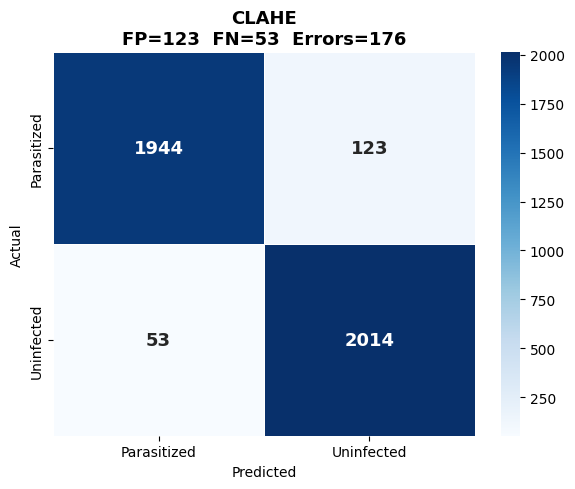

Saved: clahe_confusion_matrix.png


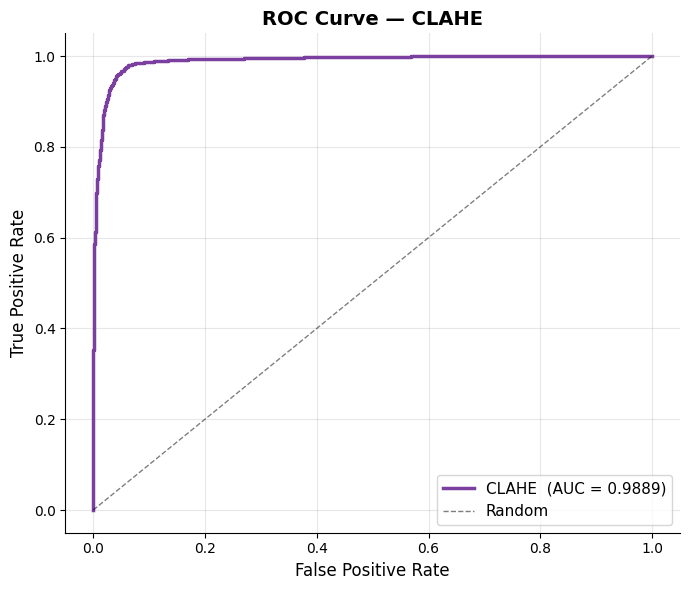

Saved: clahe_roc.png

Done. Share the results table.


In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef,
                             confusion_matrix, roc_curve, auc)

DRIVE_DIR = "/content/drive/MyDrive/cell_project"
PLOTS_DIR = os.path.join(DRIVE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load CLAHE model only
os.listdir(DRIVE_DIR)
print("Loading CLAHE model...")
clahe_model = tf.keras.models.load_model(f"{DRIVE_DIR}/best_clahe_cnn.keras")
print("Loaded.")

# Evaluate on CLAHE test set
datagen = ImageDataGenerator(rescale=1./255)
test_gen = datagen.flow_from_directory(
    f"{DRIVE_DIR}/CLAHE/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)
test_gen.reset()
y_true = test_gen.classes
y_prob = clahe_model.predict(test_gen, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
rauc = roc_auc_score(y_true, y_prob)
mcc  = matthews_corrcoef(y_true, y_pred)
cm   = confusion_matrix(y_true, y_pred)
fp   = int(cm[0][1])
fn   = int(cm[1][0])

print("\nCLAHE Results")
print("=" * 40)
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  AUC:       {rauc:.4f}")
print(f"  MCC:       {mcc:.4f}")
print(f"  FP:        {fp}")
print(f"  FN:        {fn}")
print(f"  Errors:    {fp+fn}")


# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Parasitized", "Uninfected"],
    yticklabels=["Parasitized", "Uninfected"],
    linewidths=0.5, annot_kws={"size": 13, "weight": "bold"},
    ax=ax
)
ax.set_title(f"CLAHE\nFP={fp}  FN={fn}  Errors={fp+fn}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/clahe_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: clahe_confusion_matrix.png")


# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#7B3FA0", linewidth=2.5,
        label=f"CLAHE  (AUC = {roc_auc:.4f})")
ax.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — CLAHE", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/clahe_roc.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: clahe_roc.png")

print("\nDone. Share the results table.")

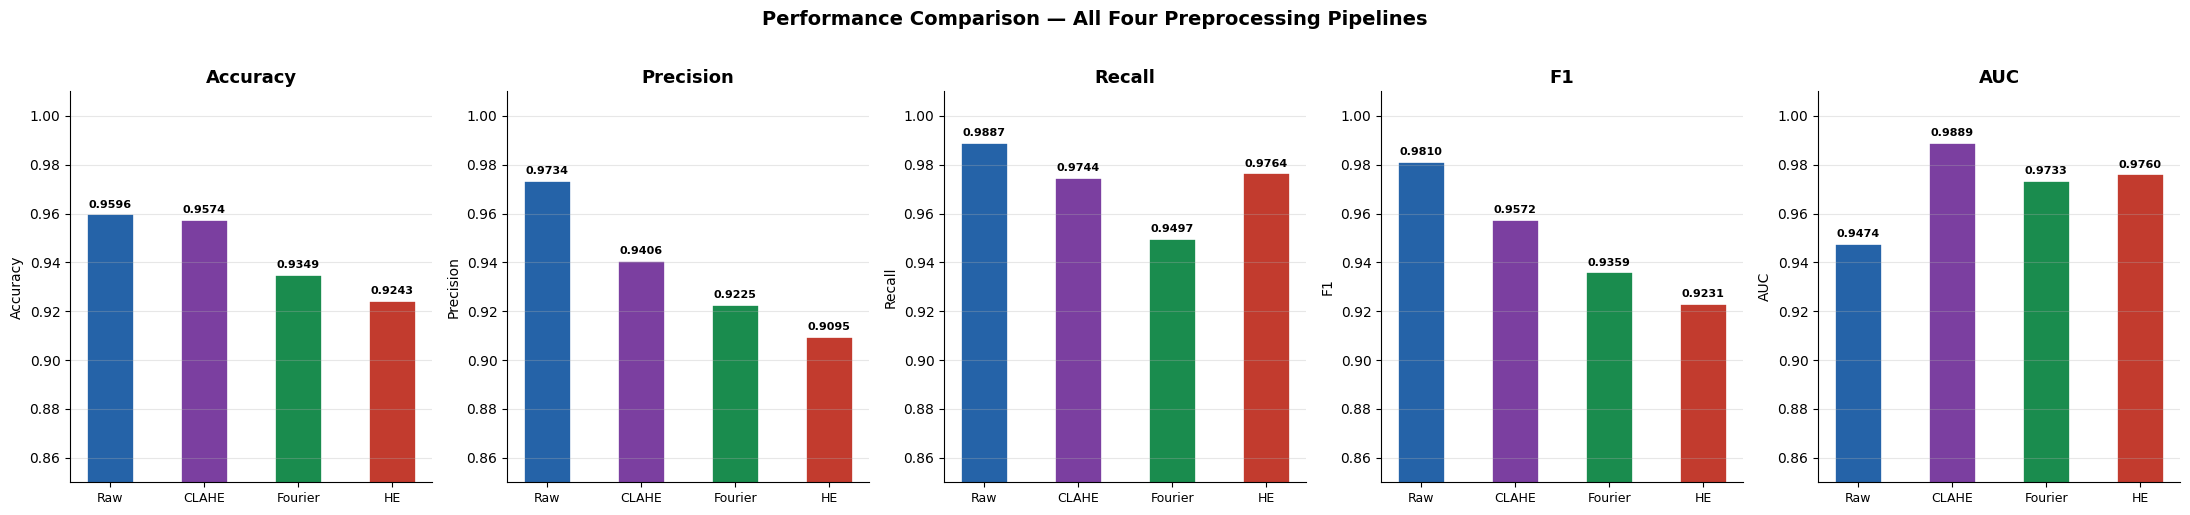

Saved: final_comparison_metrics.png


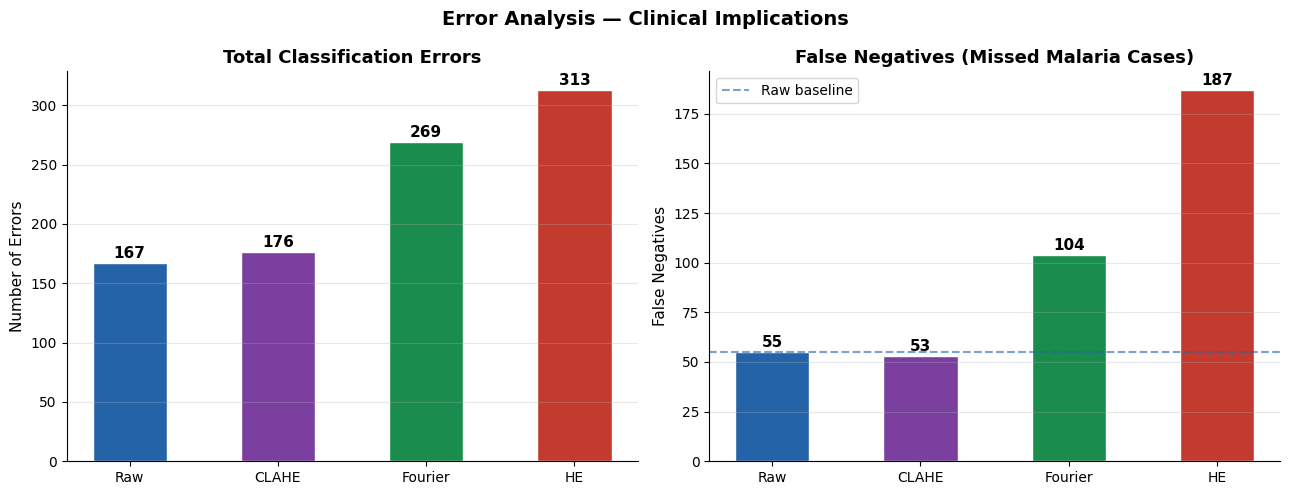

Saved: final_comparison_errors.png

Both final comparison plots saved to Drive.

Experiments are now complete. Ready to write


In [5]:
import matplotlib.pyplot as plt
import numpy as np

PLOTS_DIR = "/content/drive/MyDrive/cell_project/plots"

# All four pipeline results
pipelines = ["Raw", "CLAHE", "Fourier", "HE"]

metrics_data = {
    "Accuracy":  [0.9596, 0.9574, 0.9349, 0.9243],
    "Precision": [0.9734, 0.9406, 0.9225, 0.9095],
    "Recall":    [0.9887, 0.9744, 0.9497, 0.9764],
    "F1":        [0.9810, 0.9572, 0.9359, 0.9231],
    "AUC":       [0.9474, 0.9889, 0.9733, 0.9760],
    "Errors":    [167,    176,    269,    313],
    "FN":        [55,     53,     104,    187],
}

COLORS = {
    "Raw":     "#2563A8",
    "CLAHE":   "#7B3FA0",
    "Fourier": "#1A8C4E",
    "HE":      "#C23B2E",
}

# Plot 1: Side by side bar chart for all metrics
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
metric_names = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for i, metric in enumerate(metric_names):
    ax   = axes[i]
    vals = metrics_data[metric]
    bars = ax.bar(pipelines, vals,
                  color=[COLORS[p] for p in pipelines],
                  width=0.5, edgecolor="white", linewidth=1.2)
    ax.set_ylim(0.85, 1.01)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")

plt.suptitle("Performance Comparison — All Four Preprocessing Pipelines",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/final_comparison_metrics.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: final_comparison_metrics.png")


# Plot 2: Error and false negative comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
bars = ax1.bar(pipelines, metrics_data["Errors"],
               color=[COLORS[p] for p in pipelines],
               width=0.5, edgecolor="white")
ax1.set_title("Total Classification Errors", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Errors", fontsize=11)
ax1.grid(axis="y", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
for bar, val in zip(bars, metrics_data["Errors"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(val), ha="center", va="bottom",
             fontsize=11, fontweight="bold")

ax2 = axes[1]
bars2 = ax2.bar(pipelines, metrics_data["FN"],
                color=[COLORS[p] for p in pipelines],
                width=0.5, edgecolor="white")
ax2.set_title("False Negatives (Missed Malaria Cases)",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("False Negatives", fontsize=11)
ax2.grid(axis="y", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
for bar, val in zip(bars2, metrics_data["FN"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(val), ha="center", va="bottom",
             fontsize=11, fontweight="bold")

# Add clinical note
ax2.axhline(y=55, color=COLORS["Raw"], linestyle="--",
            linewidth=1.5, alpha=0.6, label="Raw baseline")
ax2.legend(fontsize=10)

plt.suptitle("Error Analysis — Clinical Implications",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/final_comparison_errors.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: final_comparison_errors.png")

print("\nBoth final comparison plots saved to Drive.")
print("\nExperiments are now complete. Ready to write")


Loading models...
Done.
Processing Parasitized...


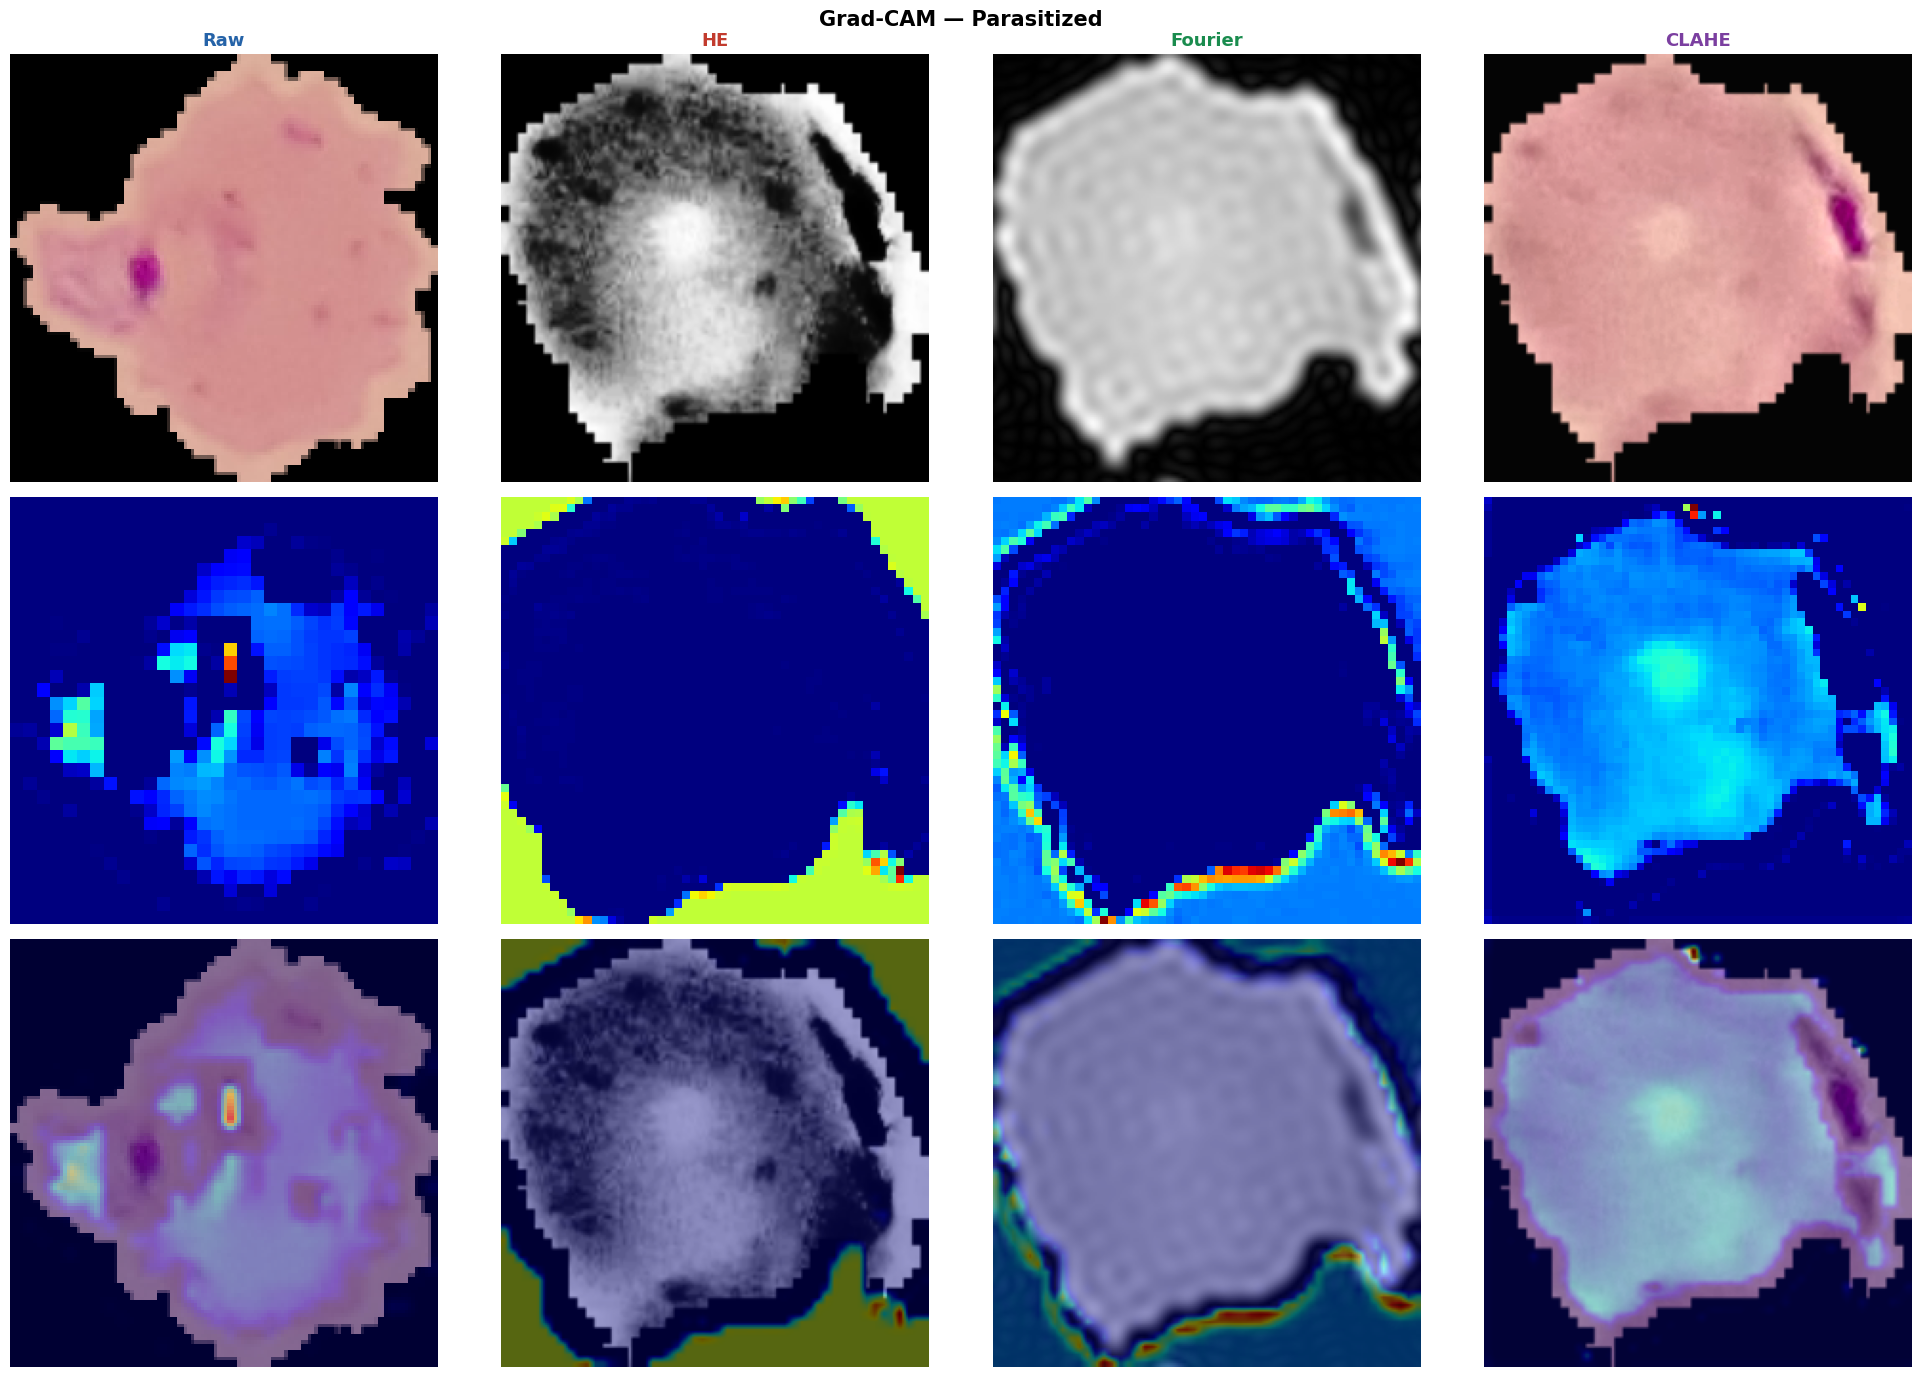

Saved: gradcam_parasitized.png
Processing Uninfected...


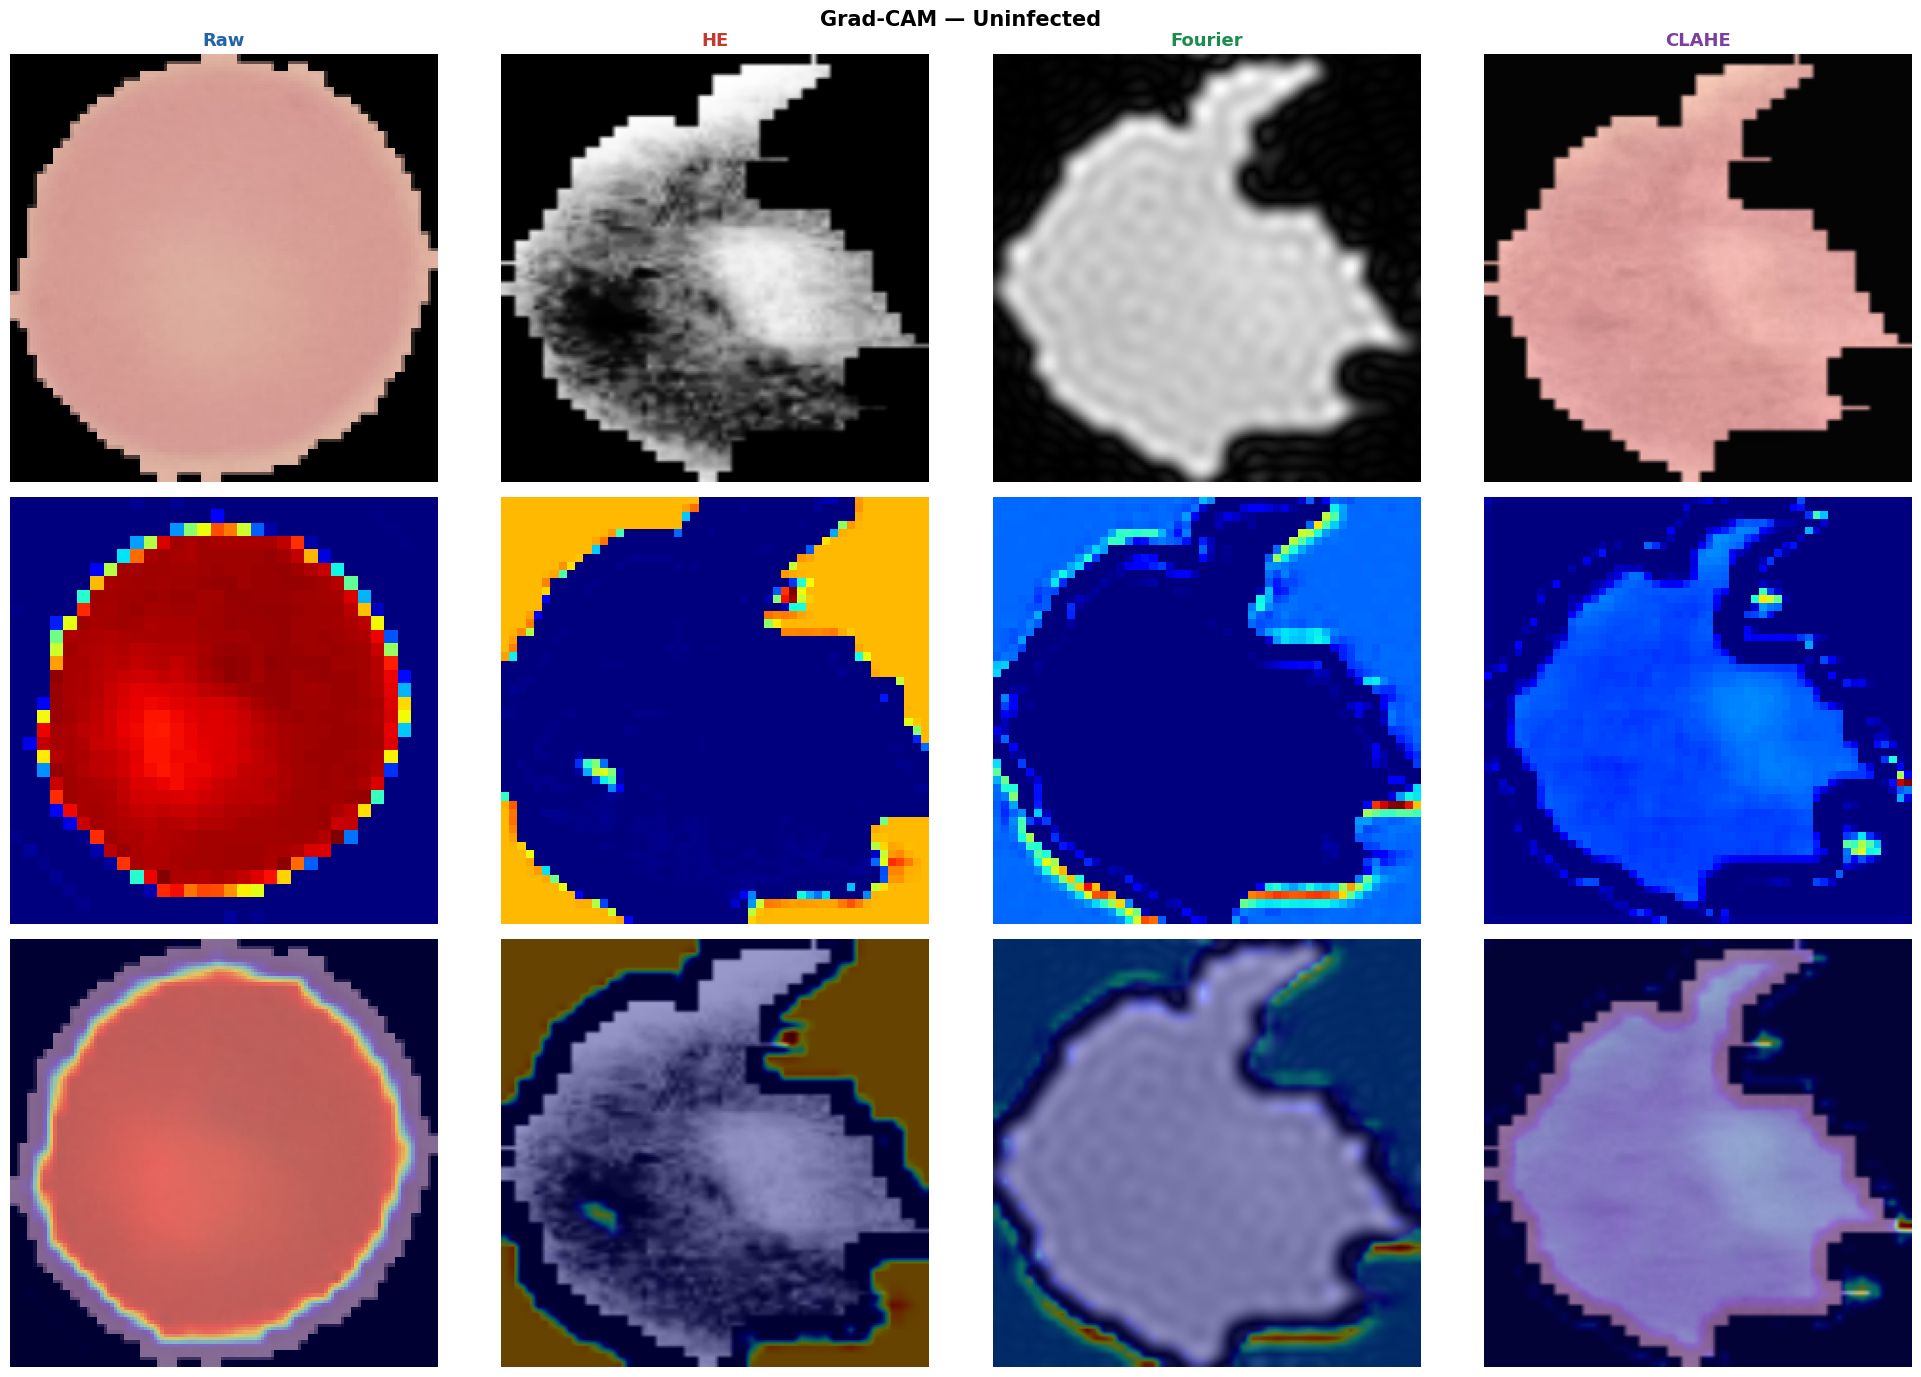

Saved: gradcam_uninfected.png
Done.


In [3]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

DRIVE_DIR = "/content/drive/MyDrive/cell_project"
PLOTS_DIR = os.path.join(DRIVE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

os.listdir(DRIVE_DIR)

print("Loading models...")
raw_model     = tf.keras.models.load_model(f"{DRIVE_DIR}/best_raw_cnn.keras")
he_model      = tf.keras.models.load_model(f"{DRIVE_DIR}/best_he_cnn.keras")
fourier_model = tf.keras.models.load_model(f"{DRIVE_DIR}/best_fourier_cnn.keras")
clahe_model   = tf.keras.models.load_model(f"{DRIVE_DIR}/best_clahe_cnn.keras")
print("Done.")


def gradcam(model, img_array):
    last_conv_layer = [l for l in model.layers
                       if isinstance(l, tf.keras.layers.Conv2D)][-1]

    # Model that outputs conv features and prediction
    feature_model = tf.keras.Sequential(
        model.layers[:model.layers.index(last_conv_layer) + 1]
    )
    pred_model = tf.keras.Sequential(
        model.layers[model.layers.index(last_conv_layer) + 1:]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        features = feature_model(img_tensor)
        tape.watch(features)
        preds = pred_model(features)
        score = preds[0][0]

    grads        = tape.gradient(score, features)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = features[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap).numpy()
    heatmap      = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap


def overlay(img_rgb, heatmap):
    h = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    h = np.uint8(255 * h)
    h = cv2.applyColorMap(h, cv2.COLORMAP_JET)
    h = cv2.cvtColor(h, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_rgb, 0.6, h, 0.4, 0)


def get_image(folder, img_size, idx=5):
    files = sorted([f for f in os.listdir(folder)
                    if f.endswith(".png") or f.endswith(".jpg")])
    img = cv2.imread(os.path.join(folder, files[idx]))
    img = cv2.resize(img, img_size)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


pipelines = [
    ("Raw",     raw_model,     (128,128), "RAW"),
    ("HE",      he_model,      (224,224), "HE"),
    ("Fourier", fourier_model, (224,224), "FOURIER_FILTERED"),
    ("CLAHE",   clahe_model,   (224,224), "CLAHE"),
]

colors = {
    "Raw":"#2563A8", "HE":"#C23B2E",
    "Fourier":"#1A8C4E", "CLAHE":"#7B3FA0"
}

for cls_name in ["Parasitized", "Uninfected"]:
    print(f"Processing {cls_name}...")
    fig, axes = plt.subplots(3, 4, figsize=(20, 14))

    for col, (name, model, size, folder) in enumerate(pipelines):
        img = get_image(
            os.path.join(DRIVE_DIR, folder, "test", cls_name),
            size, idx=5
        )
        arr  = np.expand_dims(img.astype(np.float32)/255.0, axis=0)
        prob = float(model.predict(arr, verbose=0).flatten()[0])
        pred = "Parasitized" if prob > 0.5 else "Uninfected"
        conf = prob if prob > 0.5 else 1 - prob

        hmap = gradcam(model, arr)
        over = overlay(img, hmap)

        axes[0, col].imshow(img)
        axes[0, col].set_title(name, fontsize=13,
                                fontweight="bold", color=colors[name])
        axes[0, col].axis("off")
        if col == 0:
            axes[0, col].set_ylabel("Original", fontsize=11)

        axes[1, col].imshow(hmap, cmap="jet")
        axes[1, col].axis("off")
        if col == 0:
            axes[1, col].set_ylabel("Heatmap", fontsize=11)

        axes[2, col].imshow(over)
        axes[2, col].set_xlabel(
            f"{pred} ({conf:.1%})", fontsize=10,
            color="green" if pred == cls_name else "red"
        )
        axes[2, col].axis("off")
        if col == 0:
            axes[2, col].set_ylabel("Overlay", fontsize=11)

    plt.suptitle(f"Grad-CAM — {cls_name}",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/gradcam_{cls_name.lower()}.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: gradcam_{cls_name.lower()}.png")

print("Done.")